# CPE 342 - Lab 08: Clustering Basics

| Name | Student ID |
|---|---|
| Kiatisak Markmeeshap | 67070501005 |
| Tithinan Sobking | 67070501018 |
| Thanaboon Tikaew | 67070501021 |
| Worawut Sereethai | 67070501040 |
| Chanon Lhumsa-ard | 67070501059 |
| Siriwan Yindeephot | 67070501075 |

### Overview
- **Method**: K-means (`scikit-learn`, `n_init=10`, `random_state=42`); K chosen from the elbow plot of the within-cluster SSE (K = 1 to 10) and the silhouette score (K = 2 to 10).
- **Dataset**: `clustering.xlsx` - four synthetic 2-D sets (Part I) and `WINE`, 178 wines x 13 chemical features (Part II).
- **Objective**: Part I - choose K and see where K-means fails (outliers, rings, moons, elongated clusters). Part II - standardise, keep the PCs that reach 80% of the variance, cluster the PC scores and profile the clusters.
- **Terms**: *within-cluster SSE* (sklearn's `inertia_`) = sum of squared distances from each point to its cluster centroid; *silhouette* = how much closer a point is to its own cluster than to the next one (-1 to 1, higher is better, unitless).

---

# Lab: Clustering basics

(Group of 4 to 6. Submit a single copy of pdf file per group.)

**Load necessary packages and apply custom configurations**

In [1]:
import warnings; 
warnings.filterwarnings("ignore")
warnings.simplefilter(action="ignore",category=UserWarning)
warnings.simplefilter(action="ignore",category=FutureWarning)

import matplotlib.pyplot as plt
#plt.style.use('ggplot')
plt.style.use('seaborn-v0_8-muted')
plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['grid.linestyle'] = ':'   
plt.rcParams['axes.grid'] = False

import seaborn as sns
sns.set_style("whitegrid", {'axes.grid' : False})
#sns.color_palette("RdBu", n_colors=10)

# Interactive plots embedded within the notebook
#%matplotlib notebook 
# Static images of plots embedded within the notebook
#%matplotlib inline   
%config InlineBackend.figure_formats = {'png', 'retina'}

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn as sk

#pd.options.plotting.backend = "plotly" 
# Conflict with options in original matplotlib.

print('Numpy version', np.__version__)
print('Pandas version', pd.__version__)
print('Seaborn version', sns.__version__)
print('Sklearn version', sk.__version__)

Numpy version 2.5.3
Pandas version 3.0.5
Seaborn version 0.13.2
Sklearn version 1.9.0


In [2]:
font_size=13
params = {'legend.fontsize': 'large',
          'figure.figsize': (5,4),
          'axes.labelsize': font_size,
          'axes.titlesize': font_size,
          'xtick.labelsize': font_size*0.8,
          'ytick.labelsize': font_size*0.8,
          'axes.titlepad': 25}
plt.rcParams.update(params)

# <font color='orange'>Part I: K-means Clustering<font>

### Apply K-mean clustering to dataset 1

**Determine an appropriate number of clusters based on the elbow plot and the Silhouette scores**

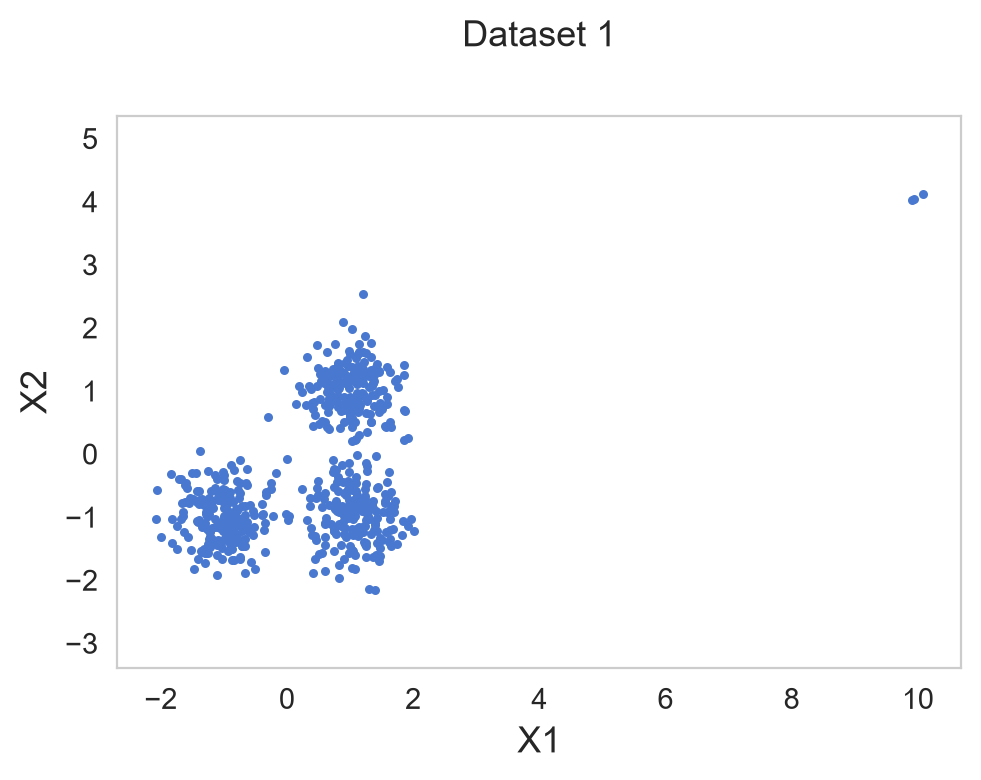

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

data = pd.read_excel('clustering.xlsx', sheet_name=None)
SEED = 42


def fit_kmeans(X, k):
    return KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X)


def show_data(X, title):
    _, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(X[:, 0], X[:, 1], s=5)
    ax.set(xlabel='X1', ylabel='X2', title=title)
    ax.set_aspect('equal', adjustable='datalim')
    plt.tight_layout()
    plt.show();


def elbow(X, title):
    sse = pd.Series({k: fit_kmeans(X, k).inertia_ for k in range(1, 11)}, name='SSE')
    _, ax = plt.subplots(figsize=(5, 4))
    ax.plot(sse.index, sse.values, marker='o', alpha=0.7, ms=8)
    ax.set(xlabel='number of clusters K', ylabel='within-cluster SSE', title=f'{title}: elbow plot', xticks=range(1, 11))
    plt.tight_layout()
    plt.show();
    print(sse.round(1).to_frame().T.to_string())
    return sse


def silhouettes(X, title):
    sil = pd.Series({k: silhouette_score(X, fit_kmeans(X, k).labels_) for k in range(2, 11)}, name='silhouette')
    _, ax = plt.subplots(figsize=(5, 4))
    ax.plot(sil.index, sil.values, marker='o', alpha=0.7, ms=8, color='tab:green')
    ax.set(xlabel='number of clusters K', ylabel='silhouette score', title=f'{title}: silhouette', xticks=range(2, 11))
    plt.tight_layout()
    plt.show();
    print(sil.round(3).to_frame().T.to_string())
    print(f'Highest silhouette: K = {sil.idxmax()} ({sil.max():.3f})')
    return sil


def show_clusters(X, ks, title):
    fig, axes = plt.subplots(1, len(ks), figsize=(5.5 * len(ks), 4.5), squeeze=False)
    for ax, k in zip(axes[0], ks):
        km = fit_kmeans(X, k)
        ax.scatter(X[:, 0], X[:, 1], c=km.labels_, s=5, cmap='Accent')
        ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], c='black', s=200, alpha=0.5)
        ax.set(xlabel='X1', ylabel='X2', title=f'{title}, K = {k}')
        ax.set_aspect('equal', adjustable='datalim')
        print(f'K = {k}: cluster sizes {np.bincount(km.labels_).tolist()}')
    plt.tight_layout()
    plt.show();


X1 = data['Dataset1'].values
show_data(X1, 'Dataset 1')

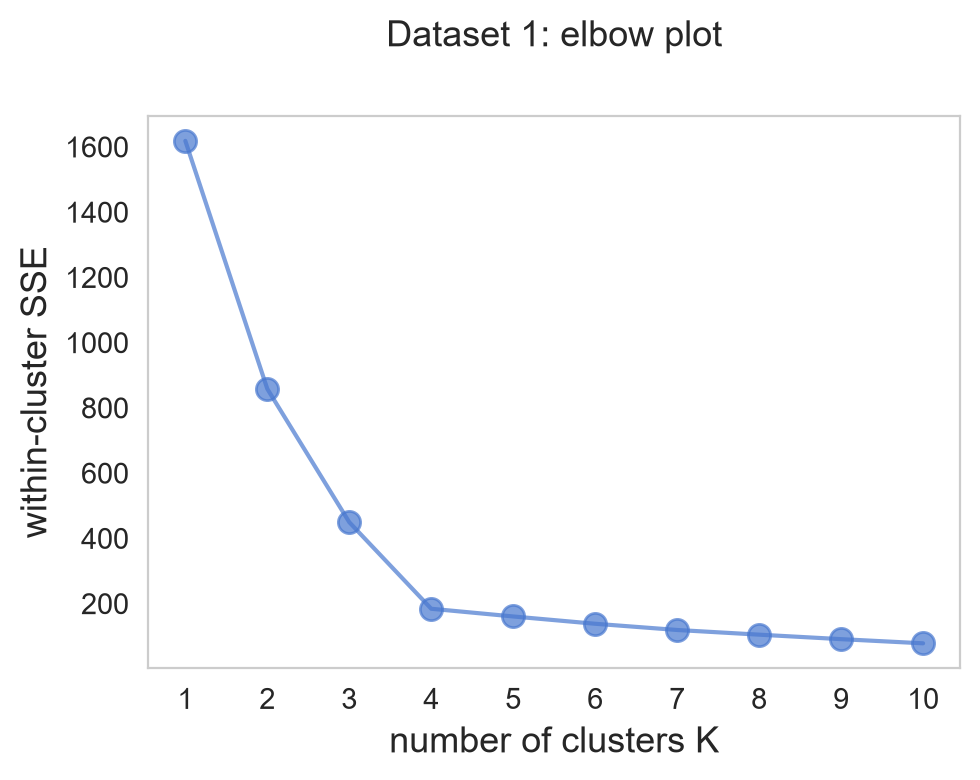

         1      2      3      4      5      6      7      8     9     10
SSE  1618.6  858.3  449.6  184.3  160.7  138.3  119.2  104.9  91.1  78.4


In [4]:
sse1 = elbow(X1, 'Dataset 1')

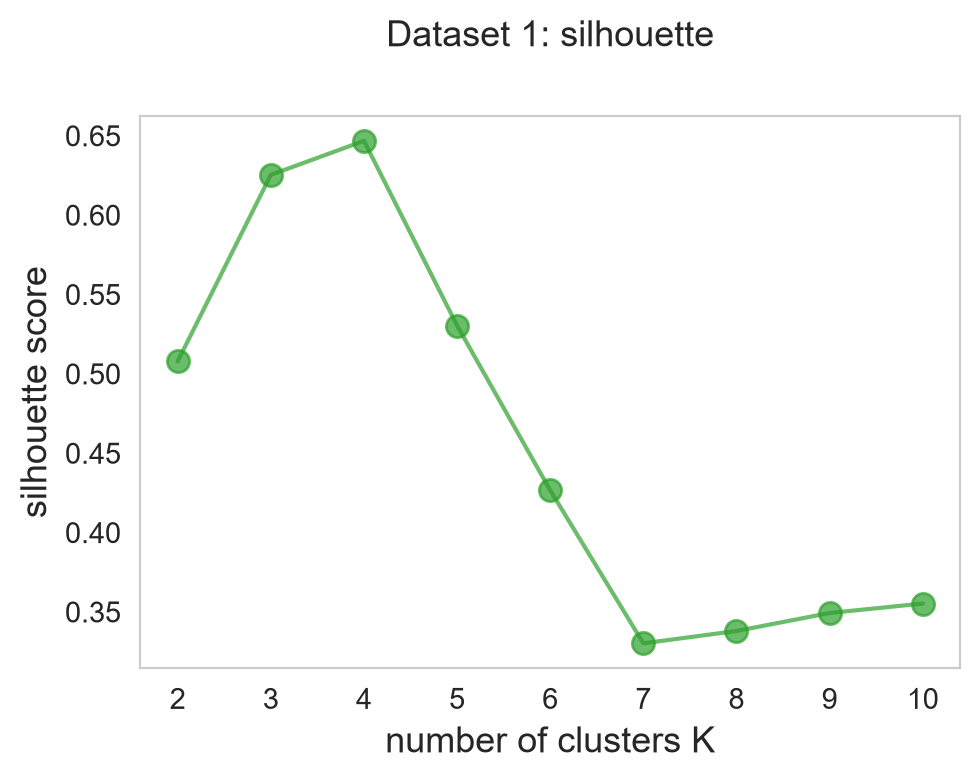

               2      3      4     5      6     7      8      9      10
silhouette  0.508  0.625  0.647  0.53  0.427  0.33  0.338  0.349  0.355
Highest silhouette: K = 4 (0.647)


In [5]:
sil1 = silhouettes(X1, 'Dataset 1')

K = 4: cluster sizes [198, 198, 201, 3]
K = 3: cluster sizes [201, 198, 201]


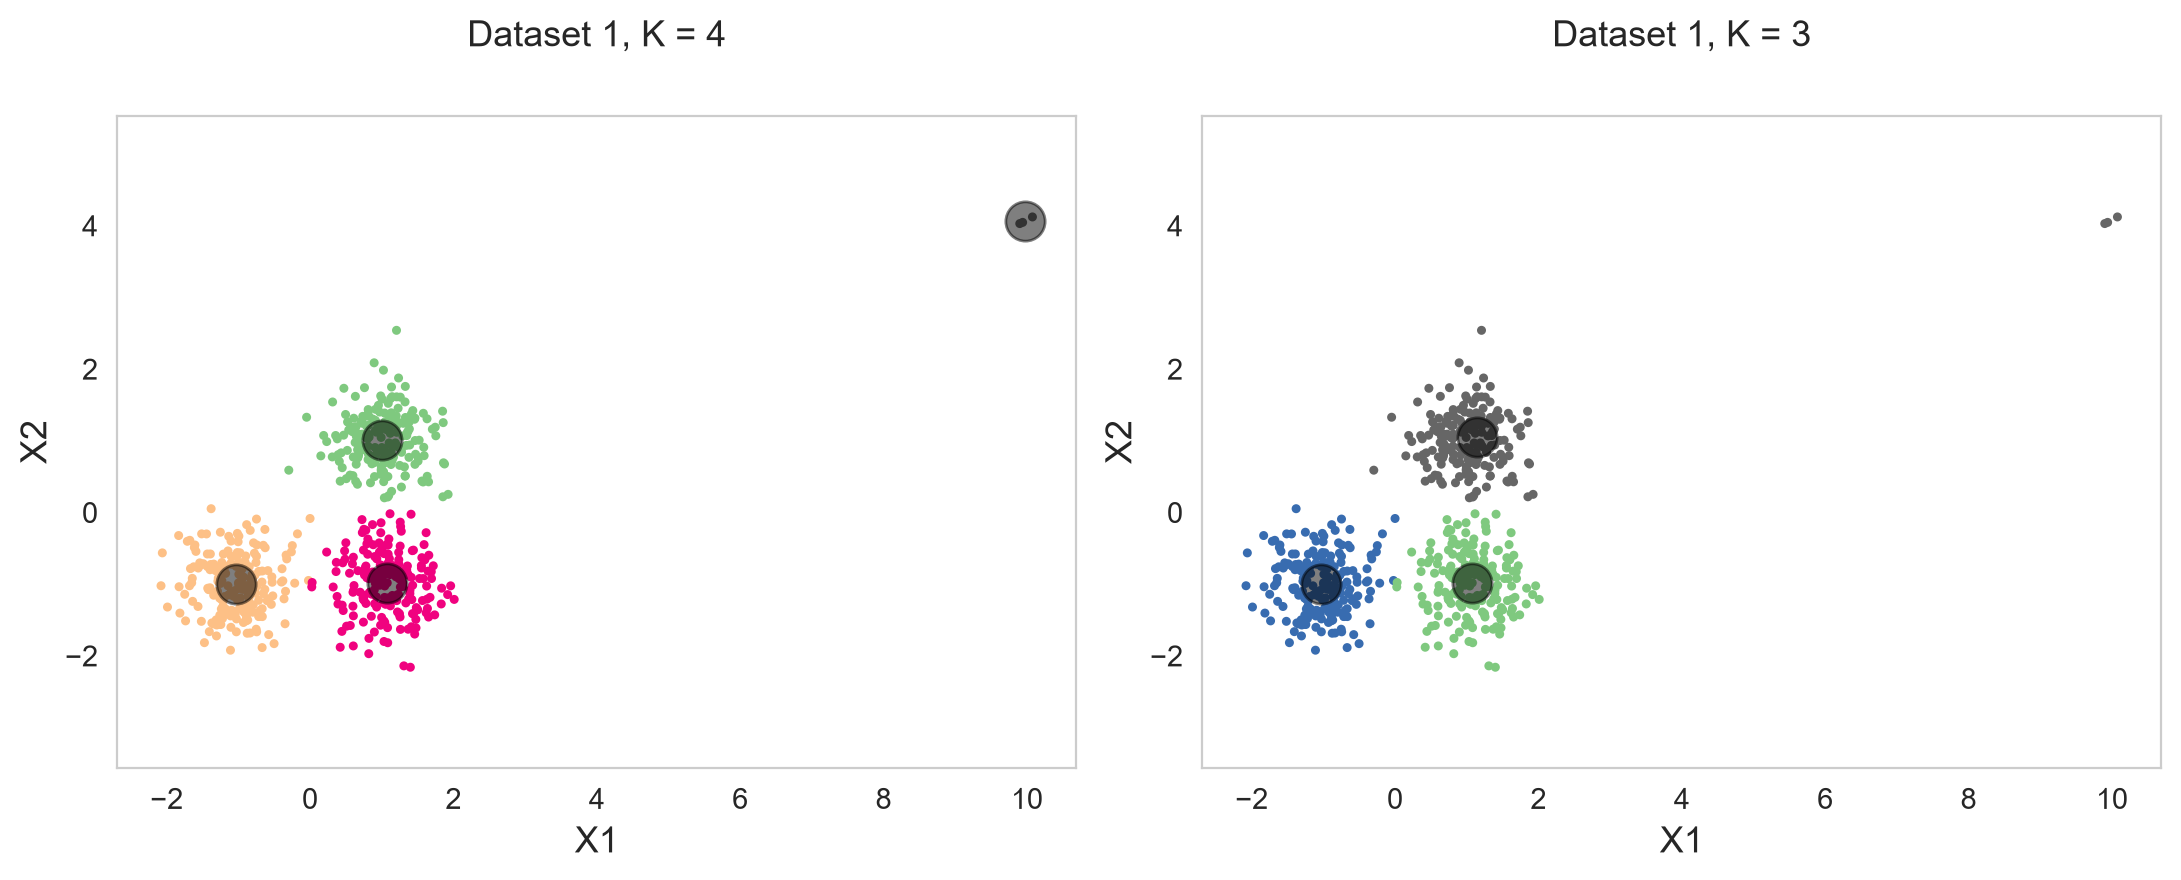

Points with X1 > 8: [[10.08, 4.12], [9.9, 4.03], [9.94, 4.05]]


In [6]:
show_clusters(X1, [4, 3], 'Dataset 1')
print('Points with X1 > 8:', X1[X1[:, 0] > 8].round(2).tolist())

In [7]:
# Dataset 1 again without the 3 outliers (X1 > 8)
X1_clean = X1[X1[:, 0] <= 8]
sil1_clean = pd.Series({k: silhouette_score(X1_clean, fit_kmeans(X1_clean, k).labels_) for k in range(2, 7)}, name='silhouette')
print(f'{len(X1) - len(X1_clean)} points removed')
print(sil1_clean.round(3).to_frame().T.to_string())
print(f'Highest silhouette: K = {sil1_clean.idxmax()} ({sil1_clean.max():.3f})')

3 points removed
                2      3      4      5      6
silhouette  0.524  0.645  0.526  0.424  0.328
Highest silhouette: K = 3 (0.645)


**Dataset 1 (standard clusters and outliers)**: the elbow is at K = 4 (within-cluster SSE 449.6 → 184.3, then 160.7) and the silhouette peaks at K = 4 (0.647). The fourth cluster is only the 3 outlier points near (10, 4). With K = 3 the outliers join the nearest cluster and pull its centroid toward them. The data hold 3 real groups plus 3 outliers: K-means has no noise label, so the metrics spend a whole cluster on them.

**Better suited**: remove the outliers first, then run K-means; without the 3 points the silhouette peaks at K = 3 (output above), the true number of groups. A density-based method such as DBSCAN avoids the problem by labelling sparse points as noise instead of forcing them into a cluster.

### Apply K-mean clustering to dataset 2

**Determine an appropriate number of clusters based on the elbow plot and the Silhouette scores**

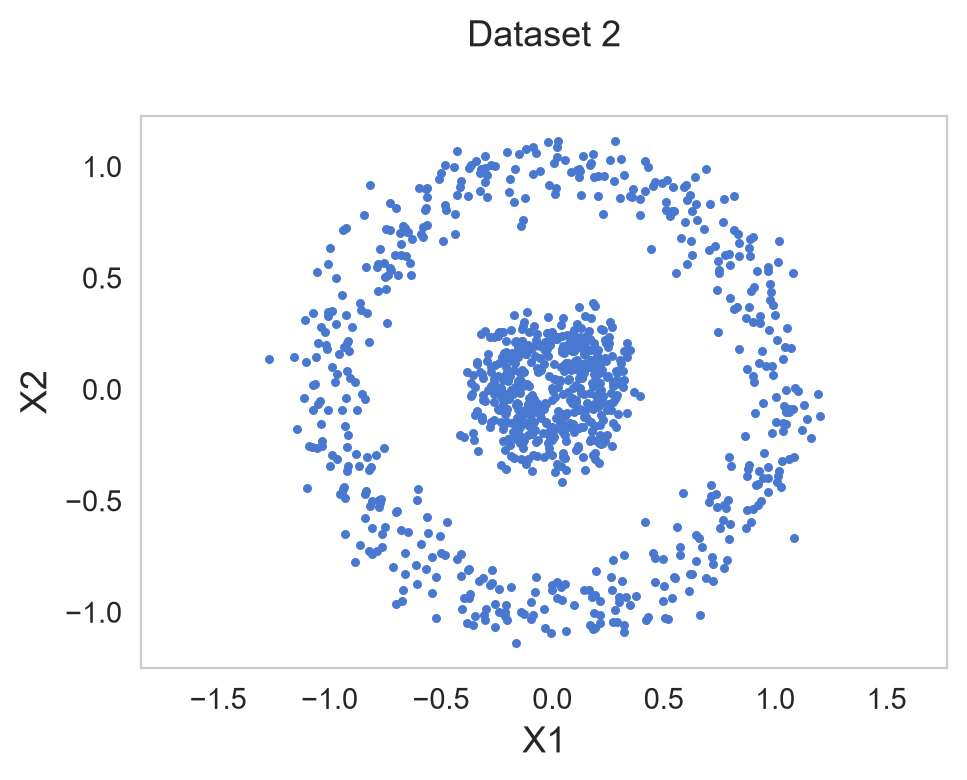

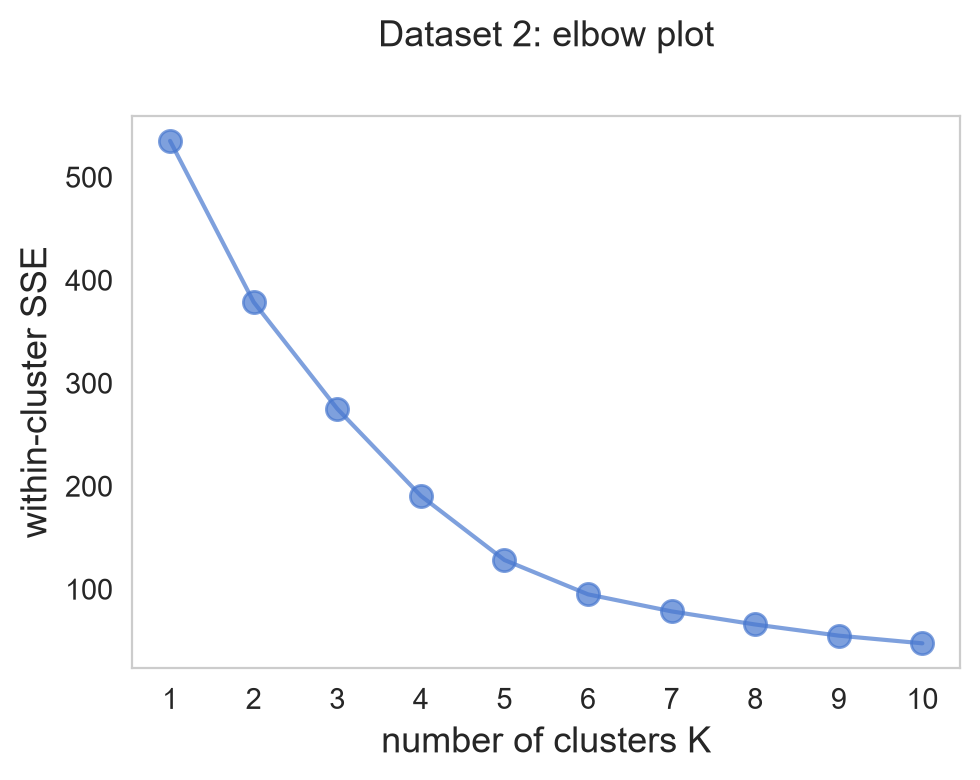

        1      2      3      4      5     6     7     8     9     10
SSE  535.3  378.8  275.2  190.6  128.3  95.0  78.4  65.7  54.9  47.4


In [8]:
X2 = data['Dataset2'].values
show_data(X2, 'Dataset 2')
sse2 = elbow(X2, 'Dataset 2')

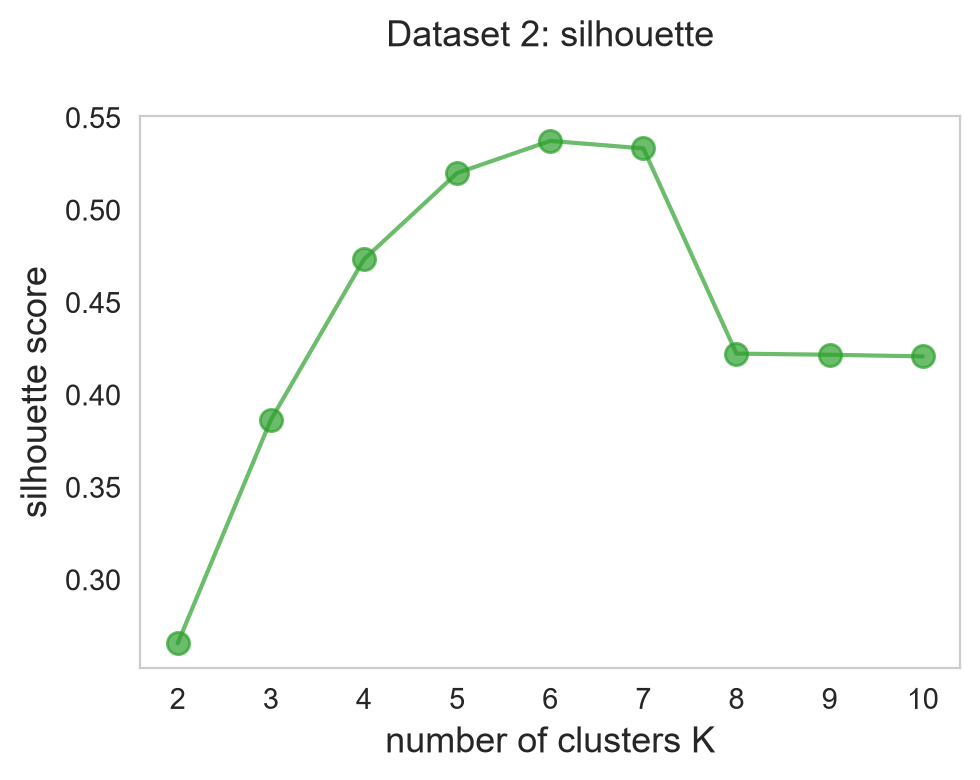

               2      3      4     5      6      7      8      9      10
silhouette  0.266  0.386  0.473  0.52  0.537  0.533  0.422  0.422  0.421
Highest silhouette: K = 6 (0.537)


In [9]:
sil2 = silhouettes(X2, 'Dataset 2')

**Fit the data and visualize the clustering**

K = 6: cluster sizes [99, 500, 102, 99, 102, 98]
K = 2: cluster sizes [526, 474]


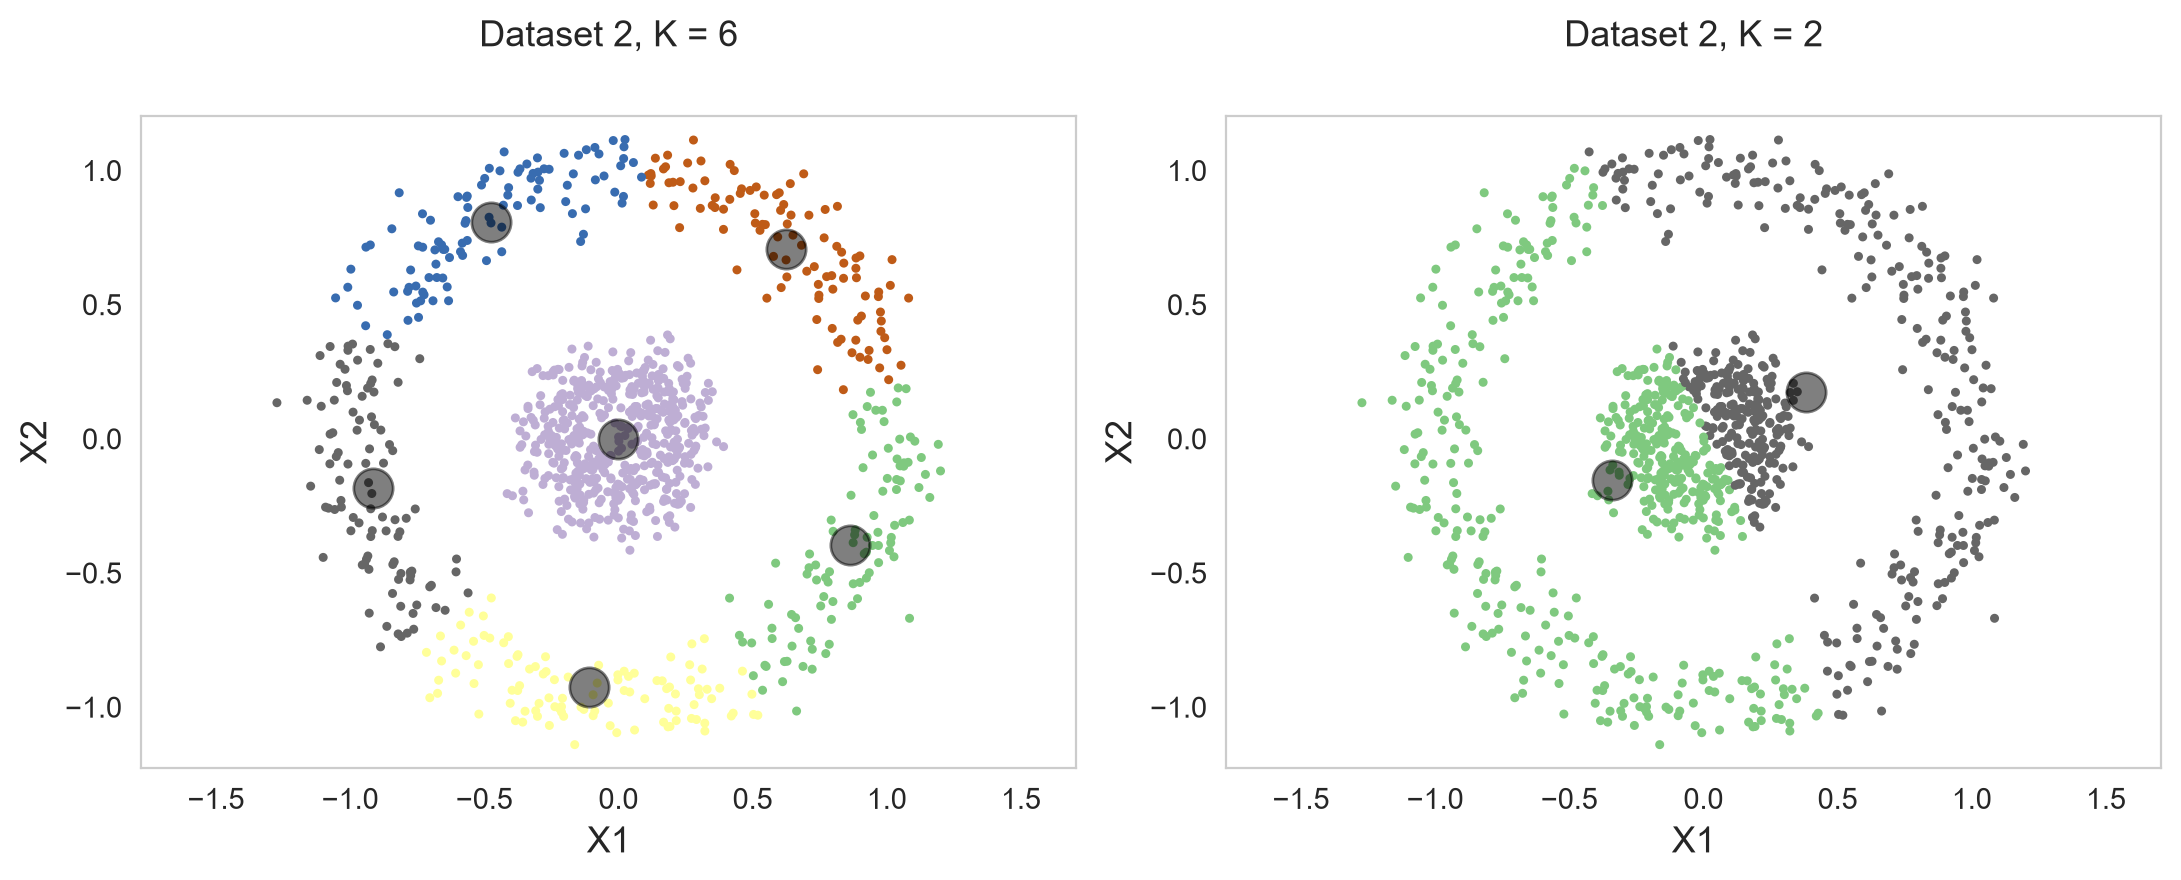

In [10]:
show_clusters(X2, [6, 2], 'Dataset 2')

**Dataset 2 (concentric rings)**: the within-cluster SSE falls smoothly with no clear elbow, and the silhouette peaks at K = 6 (0.537), which cuts the outer ring into arcs. The data are 2 groups, a ring around a core, yet K = 2 splits the plane down the middle, half of each ring on each side. K-means assigns each point to its nearest centroid, so its clusters are convex regions; a ring around a core cannot be one.

**Better suited**: DBSCAN or spectral clustering, which group points by connectivity or density. The ring is connected all the way round and is separated from the core by a gap, so linking near neighbours gives the two true groups whatever their shape.

### Apply K-mean clustering to dataset 3

**Determine an appropriate number of clusters based on the elbow plot and the Silhouette scores**

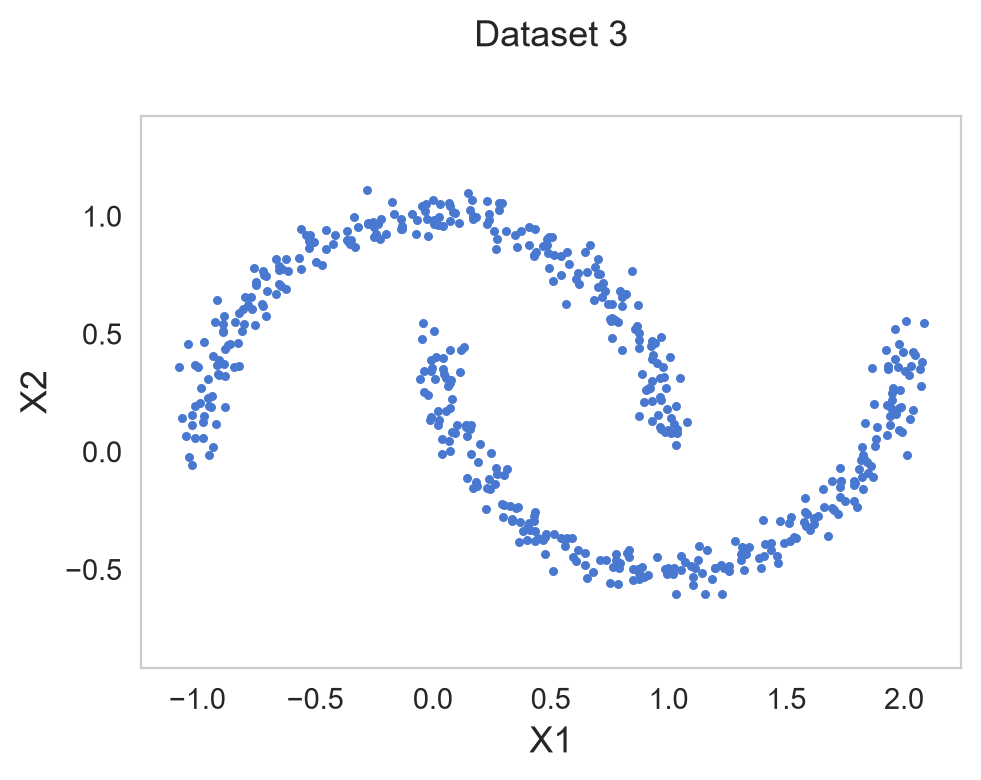

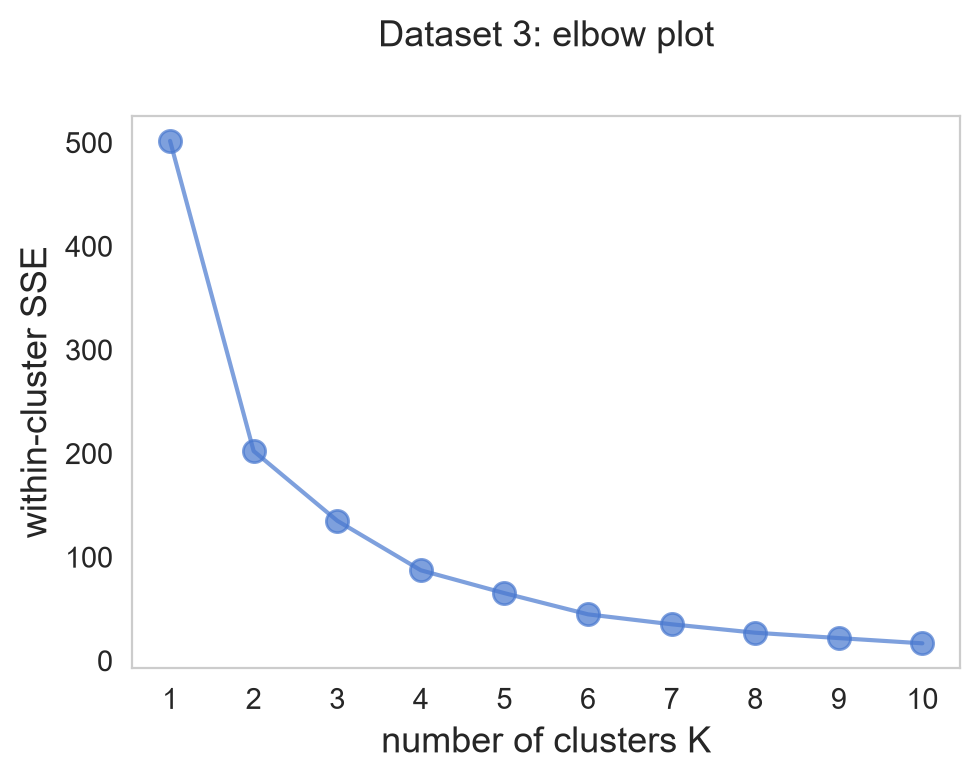

        1      2      3     4     5     6     7     8     9     10
SSE  501.8  202.4  135.1  87.3  65.3  44.8  35.2  27.1  21.9  16.9


In [11]:
X3 = data['Dataset3'].values
show_data(X3, 'Dataset 3')
sse3 = elbow(X3, 'Dataset 3')

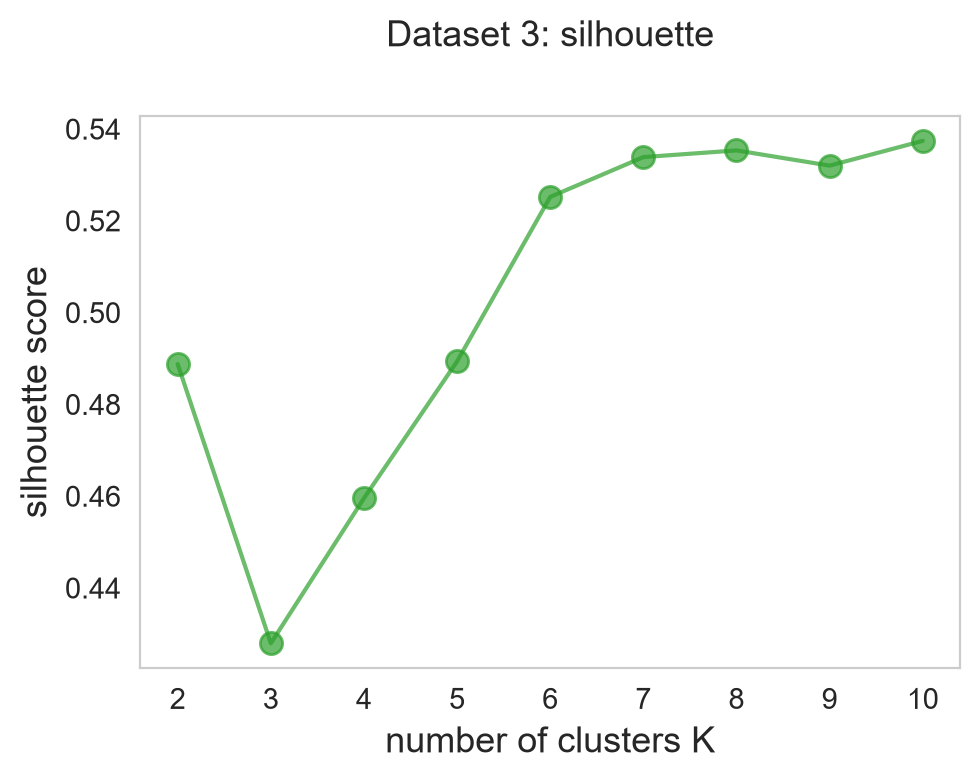

               2      3     4      5      6      7      8      9      10
silhouette  0.489  0.428  0.46  0.489  0.525  0.534  0.535  0.532  0.537
Highest silhouette: K = 10 (0.537)


In [12]:
sil3 = silhouettes(X3, 'Dataset 3')

**Fit the data and visualize the clustering**

K = 2: cluster sizes [254, 246]
K = 10: cluster sizes [47, 55, 49, 42, 51, 55, 54, 52, 49, 46]


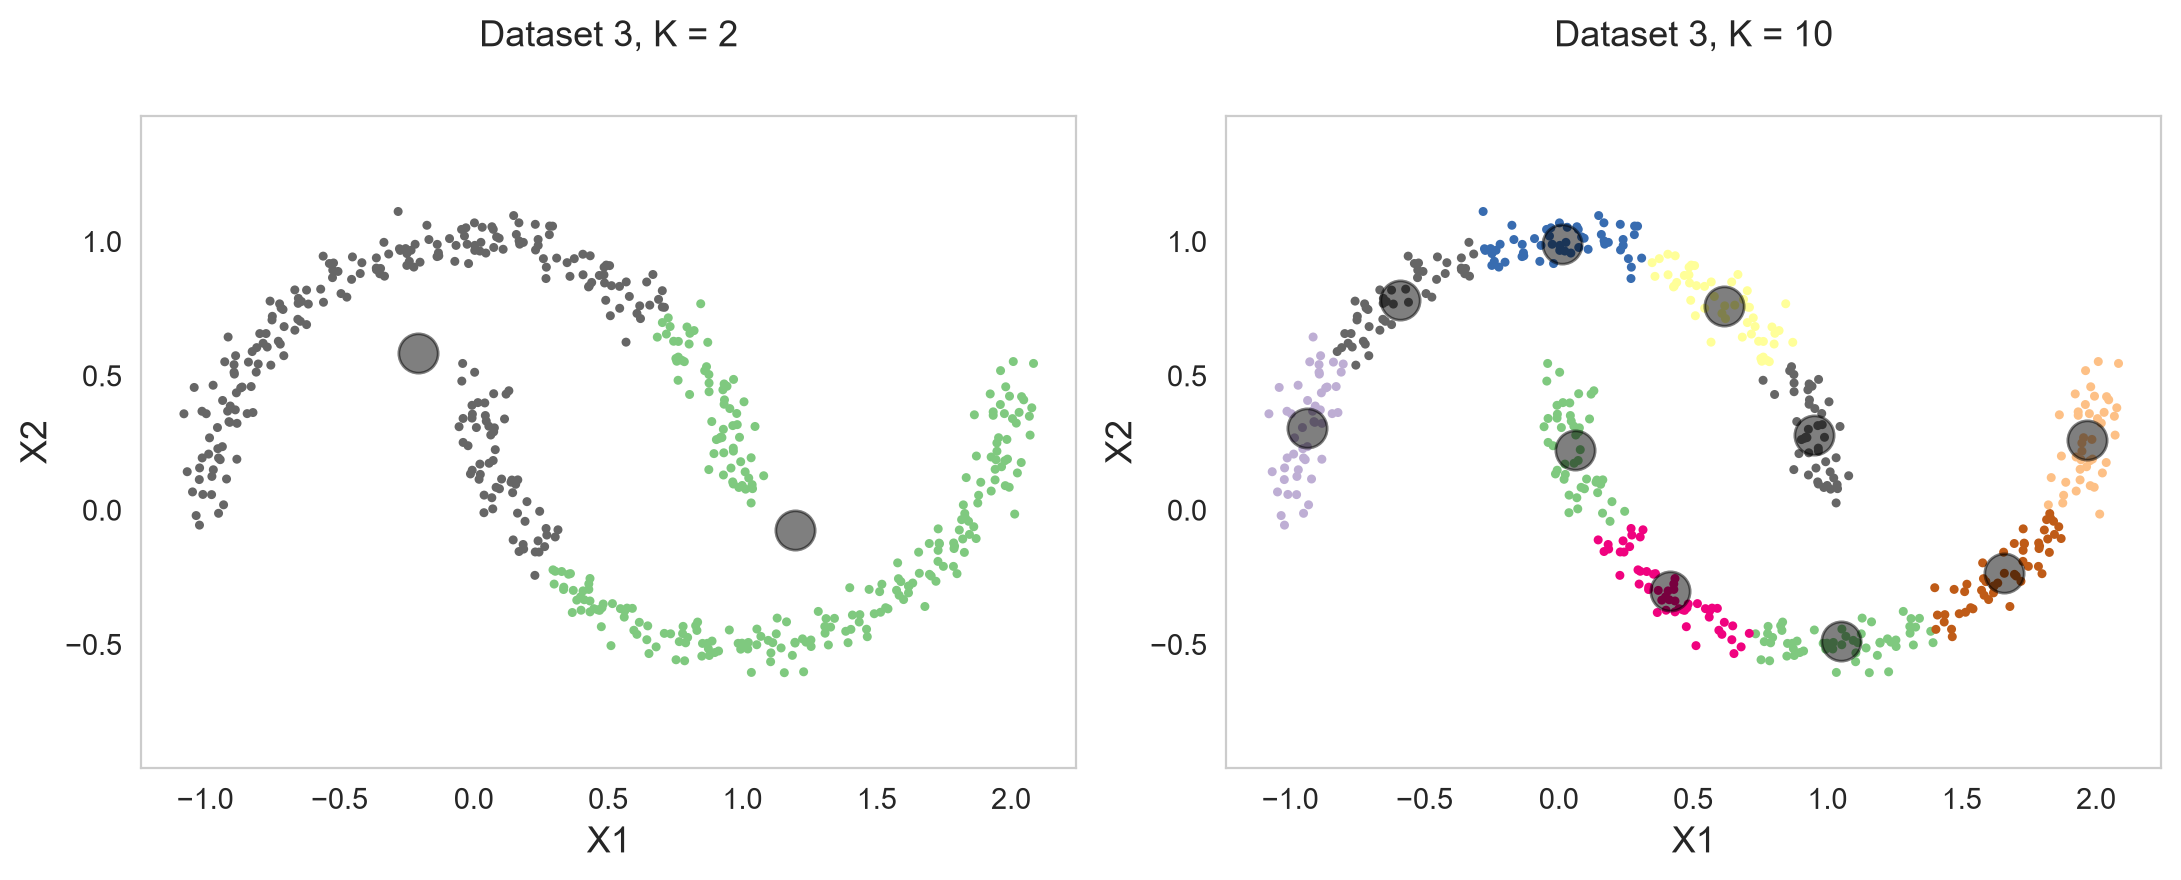

In [13]:
show_clusters(X3, [2, 10], 'Dataset 3')

**Dataset 3 (two moons)**: the elbow is at K = 2 (within-cluster SSE 501.8 → 202.4, then 135.1), but the silhouette keeps rising to K = 10 (0.537), so it gives no answer. K = 2 cuts across both moons, giving each cluster the tip of the other moon; K = 10 only chops the moons into short pieces. The moons are not globular, so no K makes K-means follow them.

**Better suited**: DBSCAN or spectral clustering. Each moon is a chain of neighbouring points and the two chains are separated by a gap, so linking each point to its near neighbours follows a moon where distance to a centroid cannot.

### Apply K-mean clustering to dataset 4

**Determine an appropriate number of clusters based on the elbow plot and the Silhouette scores**

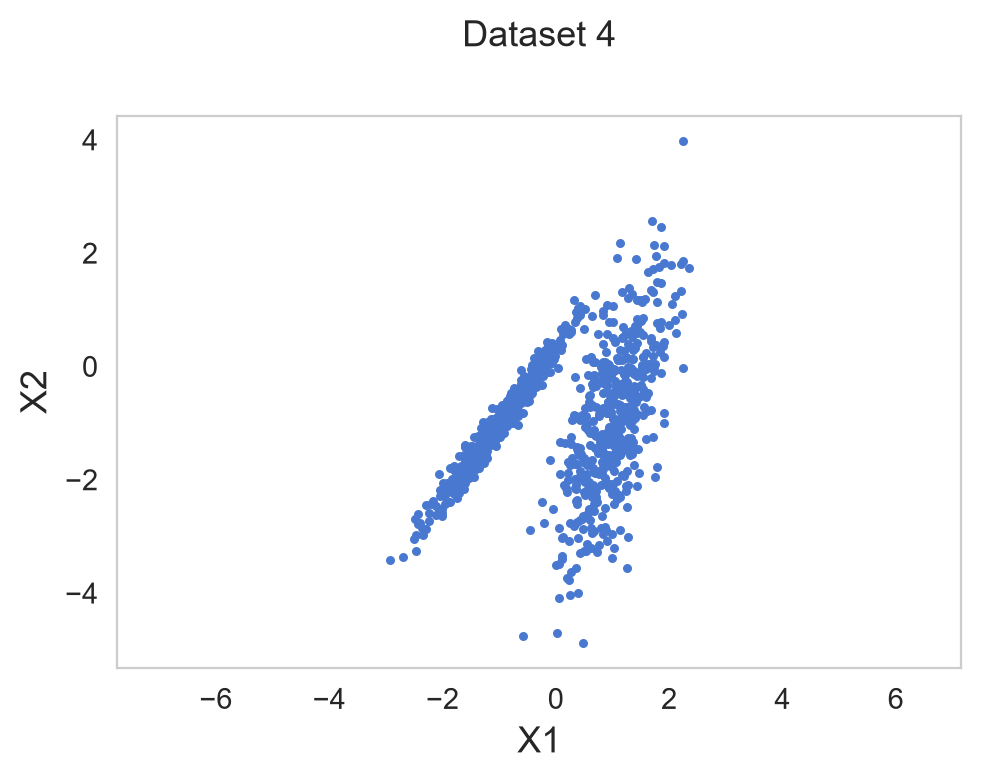

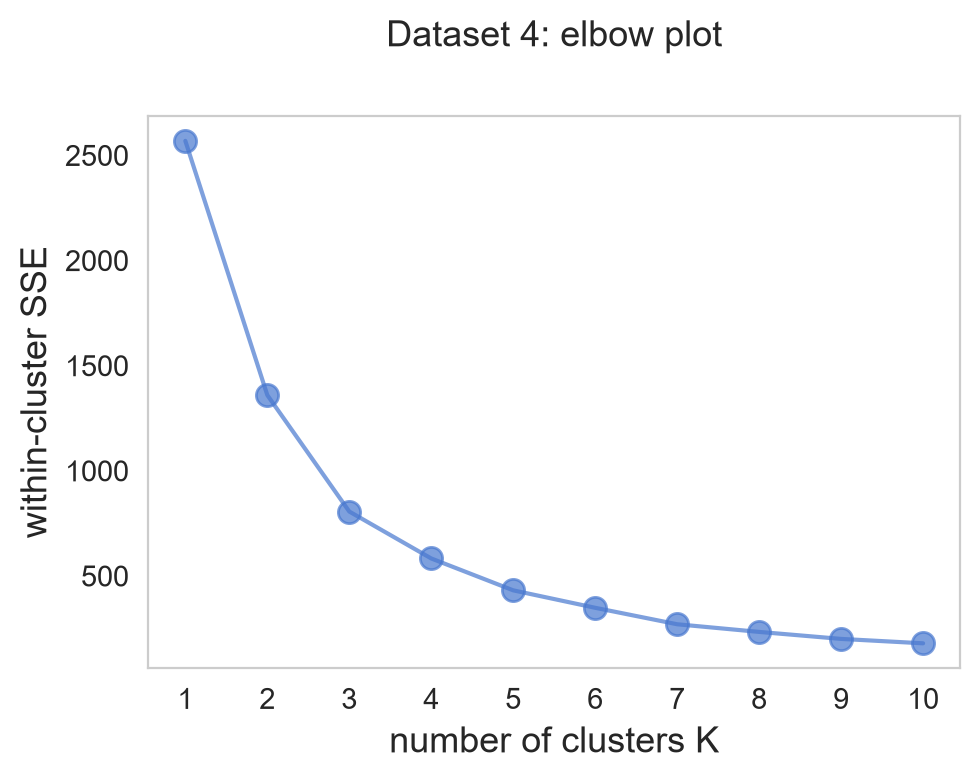

         1       2      3      4      5      6      7      8      9      10
SSE  2569.4  1360.3  806.6  583.4  431.8  348.8  270.5  234.1  200.9  179.9


In [14]:
X4 = data['Dataset4'].values
show_data(X4, 'Dataset 4')
sse4 = elbow(X4, 'Dataset 4')

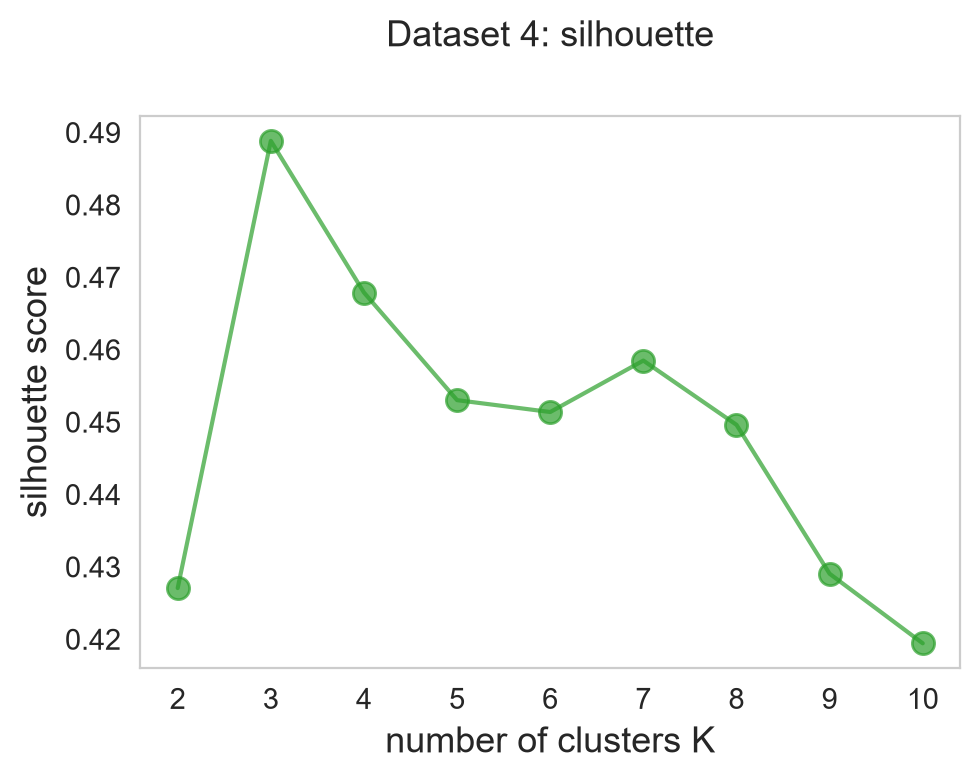

               2      3      4      5      6      7     8      9      10
silhouette  0.427  0.489  0.468  0.453  0.451  0.459  0.45  0.429  0.419
Highest silhouette: K = 3 (0.489)


In [15]:
sil4 = silhouettes(X4, 'Dataset 4')

**Fit the data and visualize the clustering**

K = 3: cluster sizes [353, 237, 410]
K = 2: cluster sizes [506, 494]


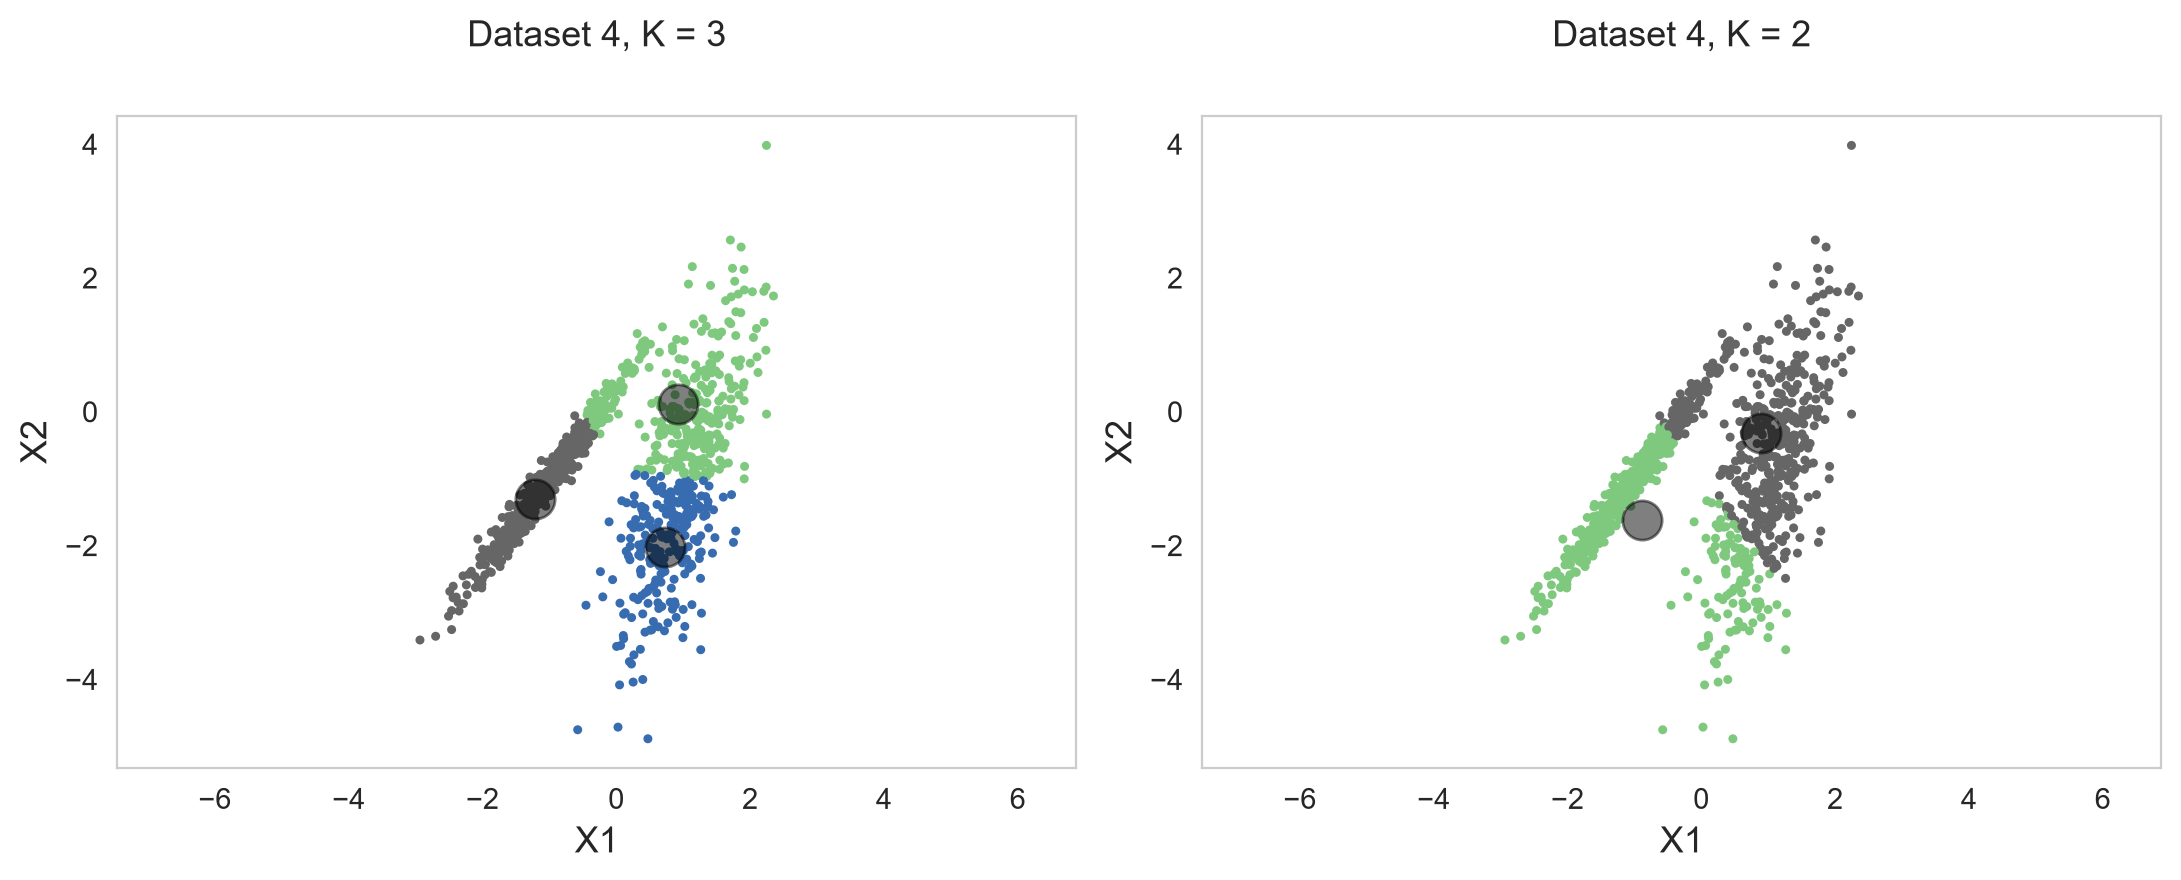

In [16]:
show_clusters(X4, [3, 2], 'Dataset 4')

**Dataset 4 (elongated clusters)**: the within-cluster SSE bends gently around K = 3 and the silhouette peaks at K = 3 (0.489). The data hold 2 groups, a long thin diagonal band and a wide vertical cloud. K = 3 cuts the cloud into an upper and a lower half and hands the top of the band to the upper half; K = 2 also mixes them, joining the lower cloud to the band. K-means minimises squared distance, so it assumes round clusters of similar spread; long or unequal clusters break that.

**Better suited**: a Gaussian mixture model (GMM). It gives each cluster its own centroid and its own tilted, elongated spread, so a thin diagonal band and a wide cloud can each be one cluster; K-means forces every cluster to the same round shape.

**Part I summary**: the elbow and silhouette pick K = 4, 6, 2 to 10, and 3, while the natural counts are 3 (+ outliers), 2, 2 and 2. The metrics only match the data when the clusters are compact, round and of similar size; in every other case, look at the data before trusting K.
In datasets 2 to 4 the problem is the shape of the groups, not the choice of K, so a different method is needed rather than a better K.

# <font color='darkorange'>Part II: Clustering Wine Data</font>

The wine dataset contatins chemical analysis of wines grown in the same region in Italy. The analysis determined the quantities of 13 constituents including
Alcohol
- Malic acid
- Ash (inorganic matter remainig after evaporation and incineration). 
- Alcalinity of ash (Ability to neutralize acids or resist changes that cause acidity)
- Magnesium
- Total phenols (Similar to alcohols but form stronger hydrogen bonds)
- Flavanoids (Compound with antioxidant properties)
- Nonflavanoid phenols
- Proanthocyanins (Compound contributing to wine color and mouthfeel properties)
- Color intensity
- Hue
- OD280/OD315 of diluted wines (Ratio of wavelength absorbance indicating taste, color, and aging characteristics)
- Proline (Amino acid to boost viscosity, sweetness and flavour) 

Apply PCA to reduce the dataset dimension that captures at least 80% of original variance.  
Then, cluster the reduced-dimension data and looks for insights from the clustering. 

## Data preprocessing

Load the dataset

In [17]:
wine = pd.read_excel('clustering.xlsx', sheet_name='WINE')
print(f'{wine.shape[0]} wines x {wine.shape[1]} features, {wine.isna().sum().sum()} missing values')
wine.describe().T[['mean', 'std', 'min', 'max']].round(2)

178 wines x 13 features, 0 missing values


,mean,std,min,max
Alcohol,13.00,0.81,11.03,14.83
Malic_Acid,2.34,1.12,0.74,5.80
Ash,2.37,0.27,1.36,3.23
Ash_Alcanity,19.49,3.34,10.60,30.00
Magnesium,99.74,14.28,70.00,162.00
Total_Phenols,2.30,0.63,0.98,3.88
Flavanoids,2.03,1.00,0.34,5.08
Nonflavanoid_Phenols,0.36,0.12,0.13,0.66
Proanthocyanins,1.59,0.57,0.41,3.58
Color_Intensity,5.06,2.32,1.28,13.00


Standardize the dataset

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Z = scaler.fit_transform(wine)

In [19]:
print('After standardising, every feature has mean 0 and standard deviation 1 (unitless):')
pd.DataFrame({'mean': Z.mean(axis=0), 'std': Z.std(axis=0)}, index=wine.columns).round(3) + 0.0   # + 0.0 turns -0.0 into 0.0

After standardising, every feature has mean 0 and standard deviation 1 (unitless):


,mean,std
Alcohol,0.0,1.0
Malic_Acid,0.0,1.0
Ash,0.0,1.0
Ash_Alcanity,0.0,1.0
Magnesium,0.0,1.0
Total_Phenols,0.0,1.0
Flavanoids,0.0,1.0
Nonflavanoid_Phenols,0.0,1.0
Proanthocyanins,0.0,1.0
Color_Intensity,0.0,1.0


## Reduce the data dimension using PCA

Apply PCA with several PCs to the standardized input data. 

In [20]:
from sklearn.decomposition import PCA

pca_full = PCA().fit(Z)
print(f'{pca_full.n_components_} PCs fitted on the standardised data')

13 PCs fitted on the standardised data


Show how each feature is weighted by the PCs.  
Which features gets relatively large weights in PC1 and PC2?

PC1, |loading| >= 0.277: {'Flavanoids': 0.423, 'Total_Phenols': 0.395, 'OD280': 0.376, 'Proanthocyanins': 0.313, 'Nonflavanoid_Phenols': -0.299, 'Hue': 0.297, 'Proline': 0.287}
PC2, |loading| >= 0.277: {'Color_Intensity': 0.53, 'Alcohol': 0.484, 'Proline': 0.365, 'Ash': 0.316, 'Magnesium': 0.3, 'Hue': -0.279}


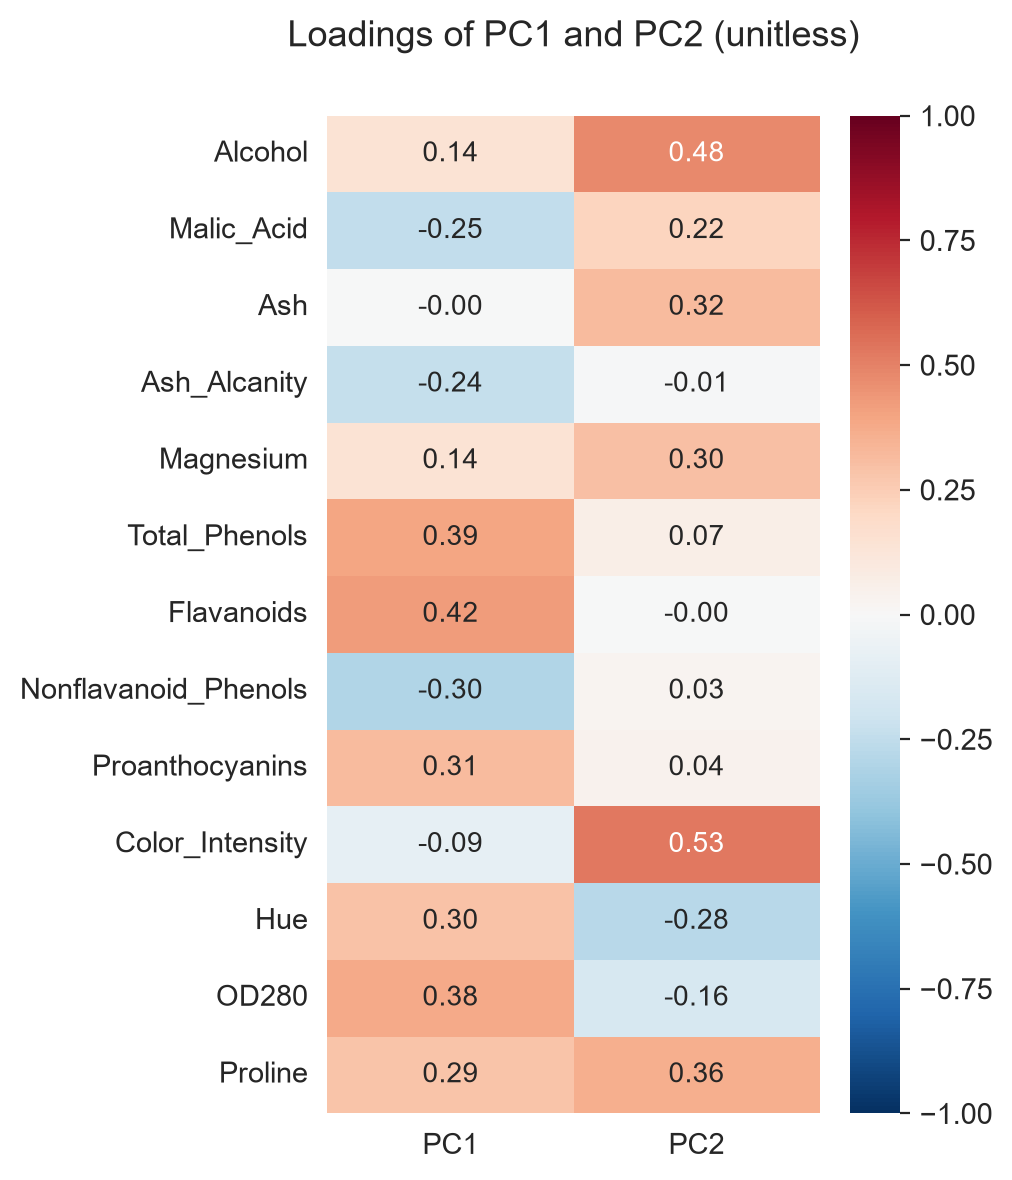

In [21]:
pc_names = [f'PC{k + 1}' for k in range(pca_full.n_components_)]
loadings = pd.DataFrame(pca_full.components_.T, index=wine.columns, columns=pc_names)
LARGE = 1 / np.sqrt(wine.shape[1])        # 0.277: the loading each feature would have if all 13 contributed equally

for pc in ['PC1', 'PC2']:
    large = loadings[pc][loadings[pc].abs() >= LARGE]
    print(f'{pc}, |loading| >= {LARGE:.3f}:', large.reindex(large.abs().sort_values(ascending=False).index).round(3).to_dict())

fig, ax = plt.subplots(figsize=(5, 6))
sns.heatmap(loadings[['PC1', 'PC2']], annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, ax=ax)
ax.set_title('Loadings of PC1 and PC2 (unitless)')
plt.tight_layout()
plt.show();

**Answer**: "large" means |loading| ≥ 1/√13 ≈ 0.277, the loading each of the 13 features would have if all contributed equally (signs are arbitrary).
- **PC1**: `Flavanoids` (0.423), `Total_Phenols` (0.395), `OD280` (0.376), `Proanthocyanins` (0.313), against `Nonflavanoid_Phenols` (−0.299); `Hue` (0.297) and `Proline` (0.287) just pass. PC1 is a phenolic-content direction.
- **PC2**: `Color_Intensity` (0.530), `Alcohol` (0.484), `Proline` (0.365), `Ash` (0.316) and `Magnesium` (0.300); `Hue` (−0.279) just passes. PC2 is an alcohol-and-colour direction.

Determine the PVE of each PC.

         PVE  cumulative PVE
PC1   0.3620          0.3620
PC2   0.1921          0.5541
PC3   0.1112          0.6653
PC4   0.0707          0.7360
PC5   0.0656          0.8016
PC6   0.0494          0.8510
PC7   0.0424          0.8934
PC8   0.0268          0.9202
PC9   0.0222          0.9424
PC10  0.0193          0.9617
PC11  0.0174          0.9791
PC12  0.0130          0.9920
PC13  0.0080          1.0000


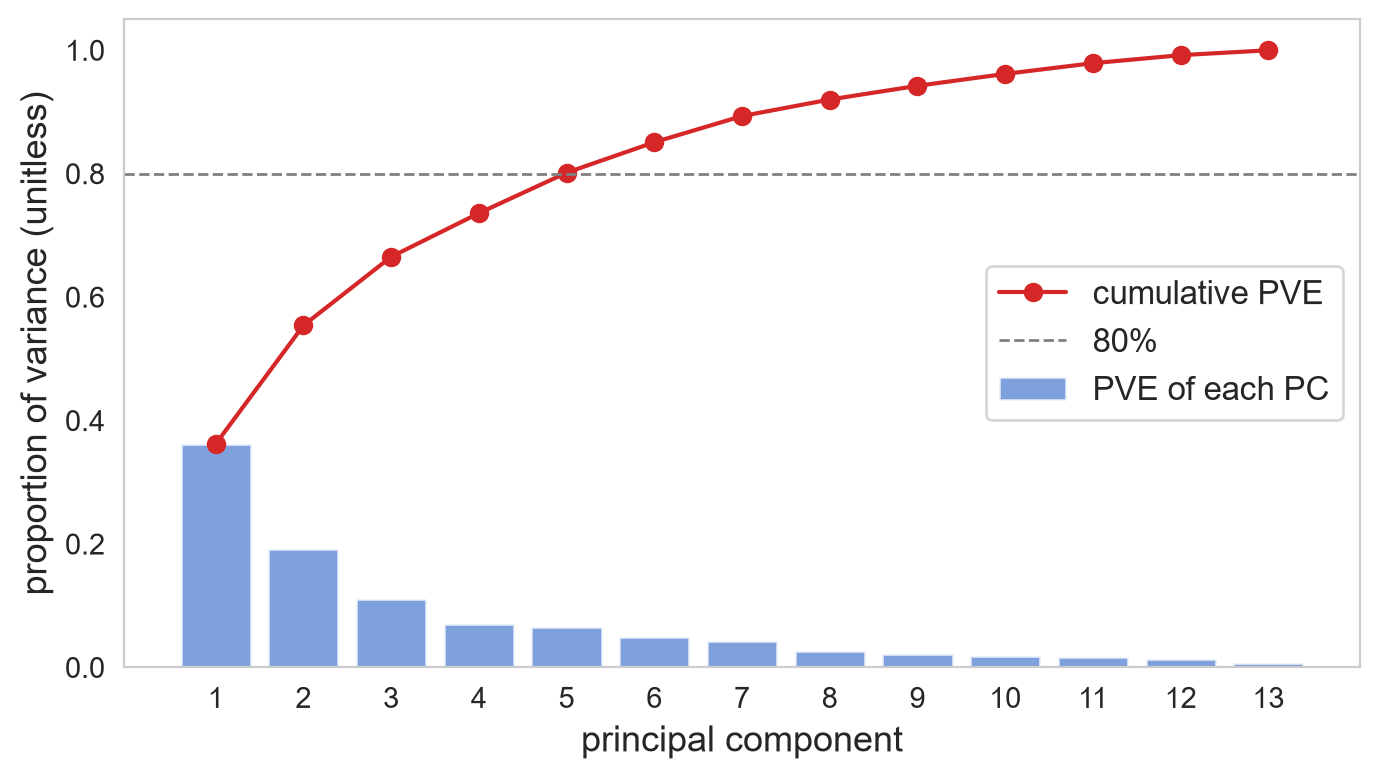

In [22]:
pve = pd.DataFrame({'PVE': pca_full.explained_variance_ratio_,
                    'cumulative PVE': np.cumsum(pca_full.explained_variance_ratio_)}, index=pc_names)
print(pve.round(4).to_string())

_, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 14), pve['PVE'], alpha=0.7, label='PVE of each PC')
ax.plot(range(1, 14), pve['cumulative PVE'], 'o-', color='tab:red', label='cumulative PVE')
ax.axhline(0.8, color='grey', ls='--', lw=1, label='80%')
ax.set(xlabel='principal component', ylabel='proportion of variance (unitless)', xticks=range(1, 14))
ax.legend(loc='center right')
plt.tight_layout()
plt.show();

Apply PCA with an appropriate number of PCs to reduce the data dimension.

In [23]:
r = int((pve['cumulative PVE'] >= 0.8).values.argmax()) + 1
pca = PCA(n_components=r).fit(Z)
scores = pca.transform(Z)
print(f'{r} PCs keep {pca.explained_variance_ratio_.sum():.1%} of the variance; scores: {scores.shape}')

5 PCs keep 80.2% of the variance; scores: (178, 5)


**Result**: 5 PCs are the fewest that reach 80% (80.2%; 4 PCs give 73.6%), so the 13 features reduce to 5 PC scores.

## K-means clustering of PC scores 

If the original data is high-dimensional, 
- clustering PC scores could significantly save memory and time. 
- clustering is easier to visualize by looking at the first few PCs.


Determine an appropriate number of clusters by looking the elbow plot and the Silhoutte scores

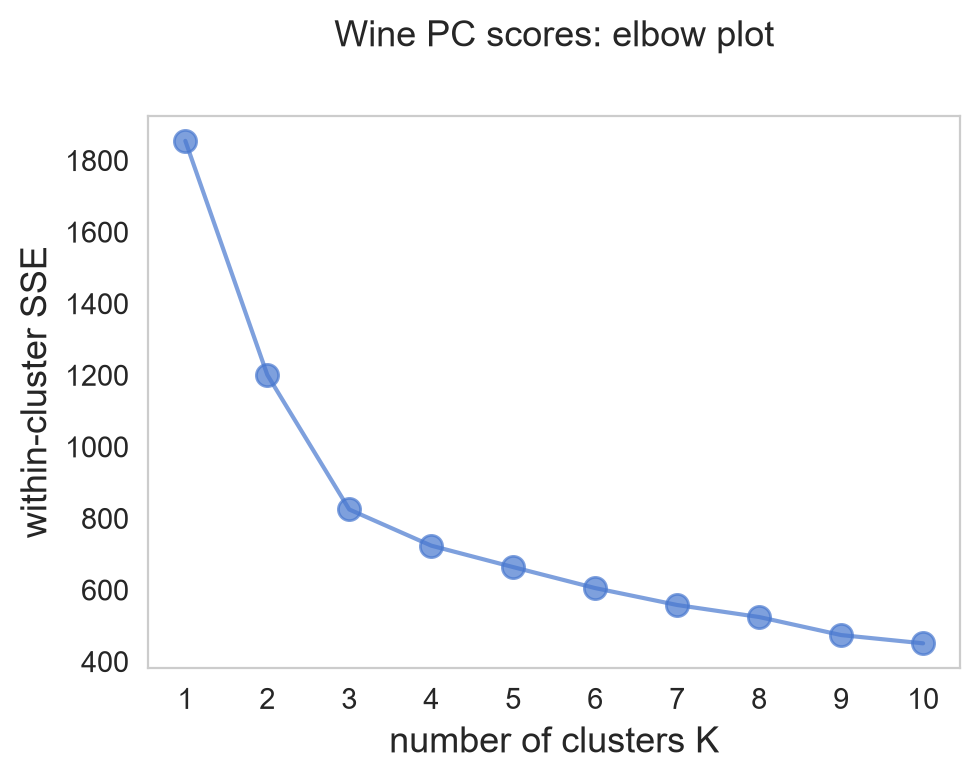

         1       2      3      4      5      6      7      8      9      10
SSE  1855.0  1201.2  825.0  723.9  664.0  605.4  558.1  524.5  474.1  451.1


In [24]:
sse_w = elbow(scores, 'Wine PC scores')

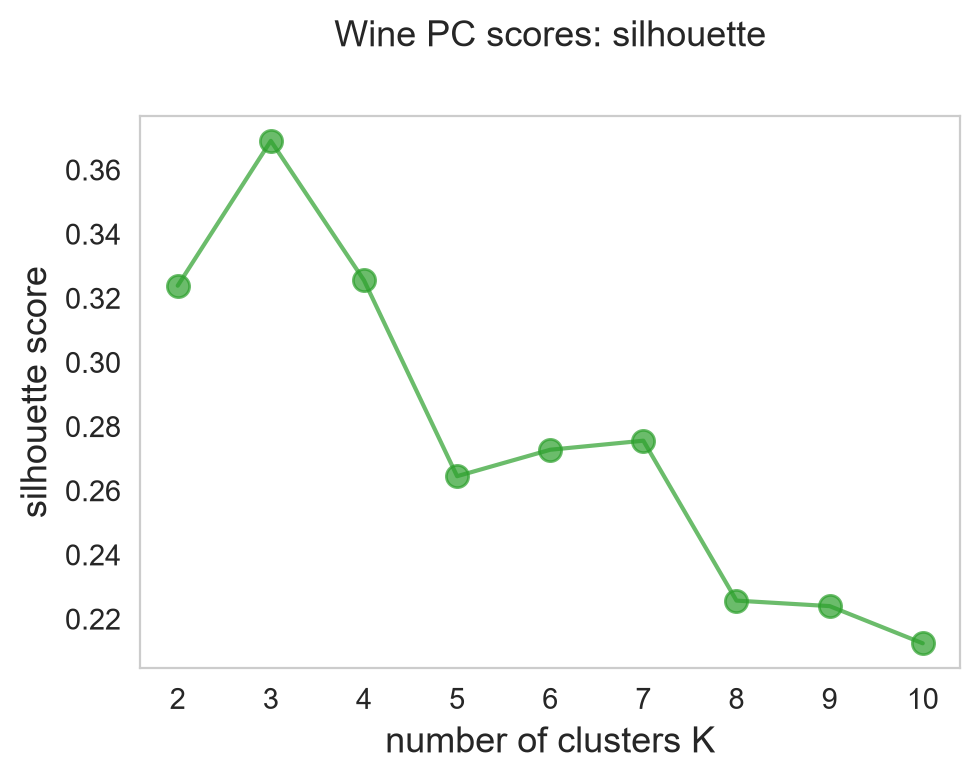

               2      3      4      5      6      7      8      9      10
silhouette  0.324  0.369  0.326  0.265  0.273  0.276  0.226  0.224  0.212
Highest silhouette: K = 3 (0.369)


In [25]:
sil_w = silhouettes(scores, 'Wine PC scores')

**Choice of K**: the elbow is at K = 3 (within-cluster SSE 1201.2 → 825.0, then 723.9) and the silhouette peaks at K = 3 (0.369). K = 3.

Fit K-means with the optimal number of clusters

In [26]:
K_WINE = 3
km_wine = fit_kmeans(scores, K_WINE)
clusters = km_wine.labels_
COLOURS = ['tab:blue', 'tab:orange', 'tab:green']          # one colour per cluster, used by every plot below
print('Cluster sizes:', np.bincount(clusters).tolist())
print('Centroids in PC-score space:')
pd.DataFrame(km_wine.cluster_centers_, columns=pc_names[:r]).round(2)

Cluster sizes: [65, 51, 62]
Centroids in PC-score space:


,PC1,PC2,PC3,PC4,PC5
0,-0.04,-1.77,0.19,0.08,0.07
1,-2.72,1.13,-0.24,0.06,0.07
2,2.28,0.93,0.00,-0.14,-0.13


## Visualize the clustering 

                      cluster 0 (n = 65)  cluster 1 (n = 51)  cluster 2 (n = 62)
Alcohol                            12.25               13.13               13.68
Malic_Acid                          1.90                3.31                2.00
Ash                                 2.23                2.42                2.47
Ash_Alcanity                       20.06               21.24               17.46
Magnesium                          92.74               98.67              107.97
Total_Phenols                       2.25                1.68                2.85
Flavanoids                          2.05                0.82                3.00
Nonflavanoid_Phenols                0.36                0.45                0.29
Proanthocyanins                     1.62                1.15                1.92
Color_Intensity                     2.97                7.23                5.45
Hue                                 1.06                0.69                1.07
OD280                       

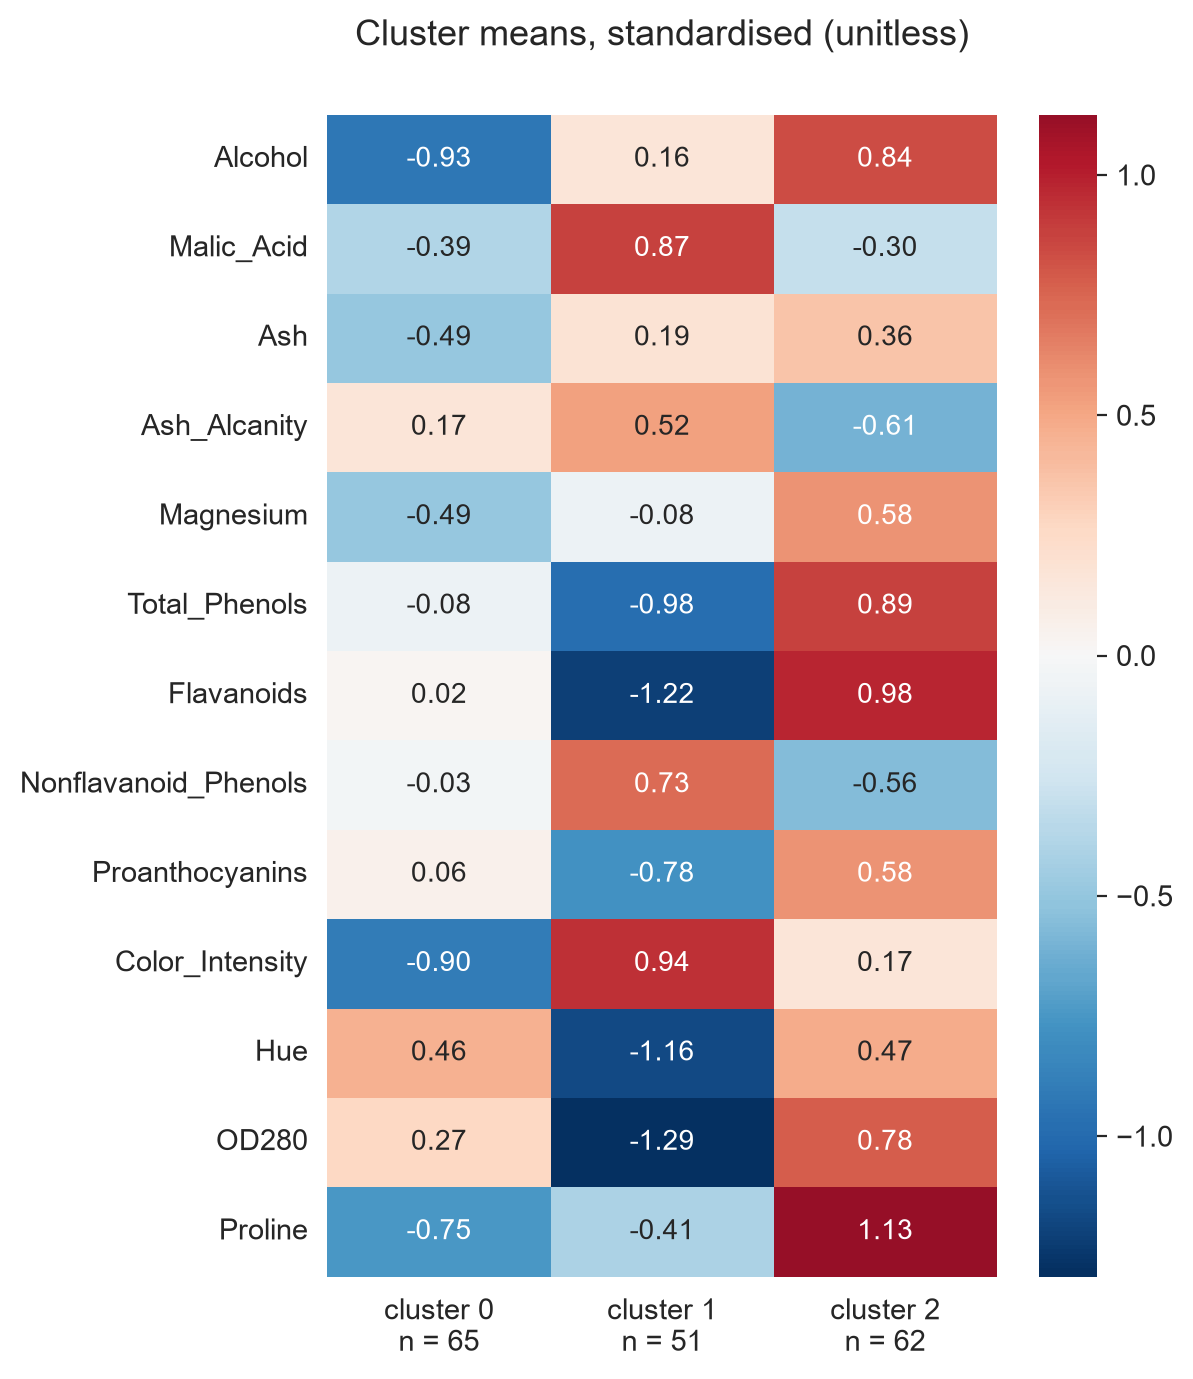

In [27]:
# Clustering profile: size, and the mean of every feature per cluster in its original units
profile = wine.groupby(clusters).mean().T
profile.columns = [f'cluster {c} (n = {n})' for c, n in enumerate(np.bincount(clusters))]
print(profile.round(2).to_string())

# The same means on the standardised scale, so features can be compared with each other
std_means = pd.DataFrame(Z, columns=wine.columns).groupby(clusters).mean().T
std_means.columns = [f'cluster {c}\nn = {n}' for c, n in enumerate(np.bincount(clusters))]
fig, ax = plt.subplots(figsize=(6, 7))
sns.heatmap(std_means, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Cluster means, standardised (unitless)')
plt.tight_layout()
plt.show();

**Reading the profile** (heatmap values are standardised means; 0 = the average of all 178 wines).
- **Cluster 0 (65 wines)**: low `Alcohol` (−0.93), `Color_Intensity` (−0.90) and `Proline` (−0.75); the phenolic features sit near the average (`Flavanoids` 0.02, `Total_Phenols` −0.08).
- **Cluster 1 (51 wines)**: lowest `OD280` (−1.29), `Flavanoids` (−1.22), `Hue` (−1.16) and `Total_Phenols` (−0.98); highest `Color_Intensity` (0.94), `Malic_Acid` (0.87) and `Nonflavanoid_Phenols` (0.73).
- **Cluster 2 (62 wines)**: highest `Proline` (1.13), `Flavanoids` (0.98), `Total_Phenols` (0.89), `Alcohol` (0.84) and `OD280` (0.78); lowest `Ash_Alcanity` (−0.61).
- Clusters 1 and 2 are mirror images on the phenolic features; cluster 0 differs from both mainly in alcohol, colour and proline.

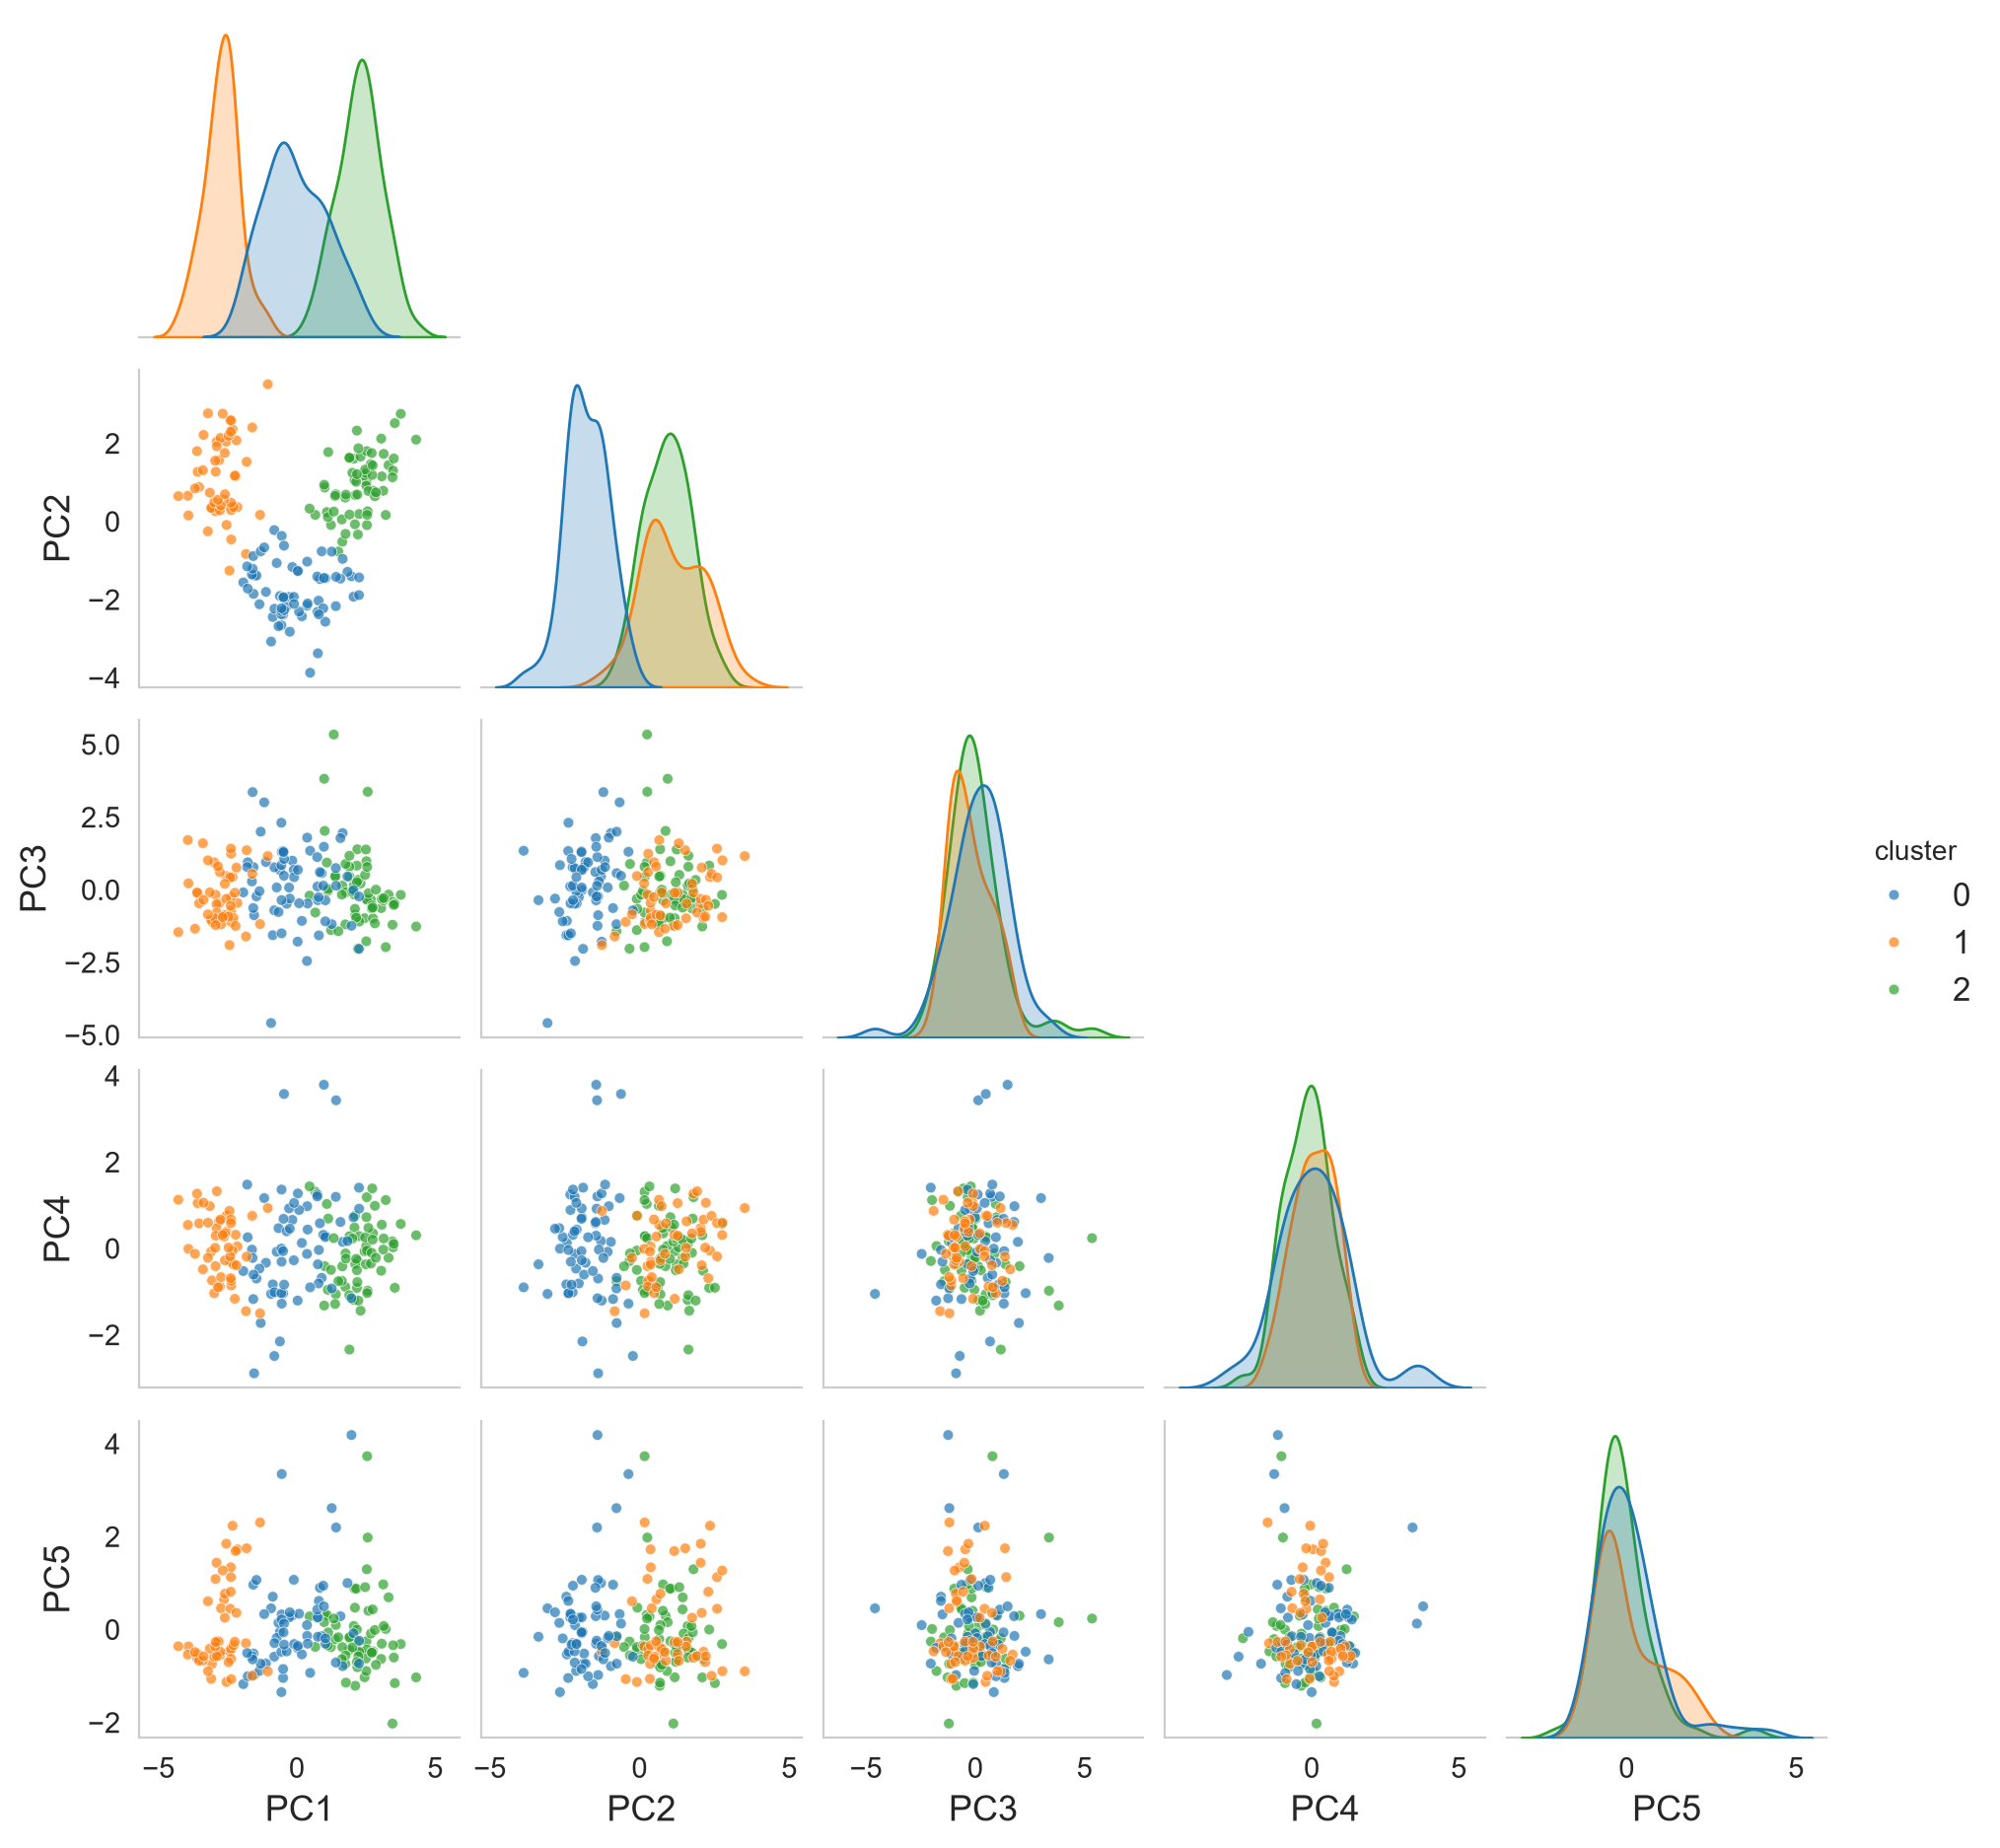

In [28]:
# Pairwise view of the 5 PC scores, coloured by cluster
pairs = pd.DataFrame(scores, columns=pc_names[:r]).assign(cluster=clusters.astype(str))
sns.pairplot(pairs, hue='cluster', hue_order=['0', '1', '2'], palette=COLOURS, corner=True, plot_kws=dict(s=15, alpha=0.7), height=1.9)
plt.show();

**Reading the pairwise view.**
- **PC1** separates clusters 1 and 2 (their PC1 distributions barely overlap) with cluster 0 in between; **PC2** separates cluster 0 (low) from the other two, whose PC2 distributions overlap.
- **PC3, PC4 and PC5**: the distributions of the three clusters overlap almost completely, so these PCs do not separate them; the few extreme scores (beyond ±3) are mostly in clusters 0 and 2.
- The grouping therefore needs only PC1 and PC2; the other three PCs are kept to reach 80% of the variance, not for the clusters.

Agreement with K-means on all 13 standardised features, adjusted Rand index (1 = identical): 1.000


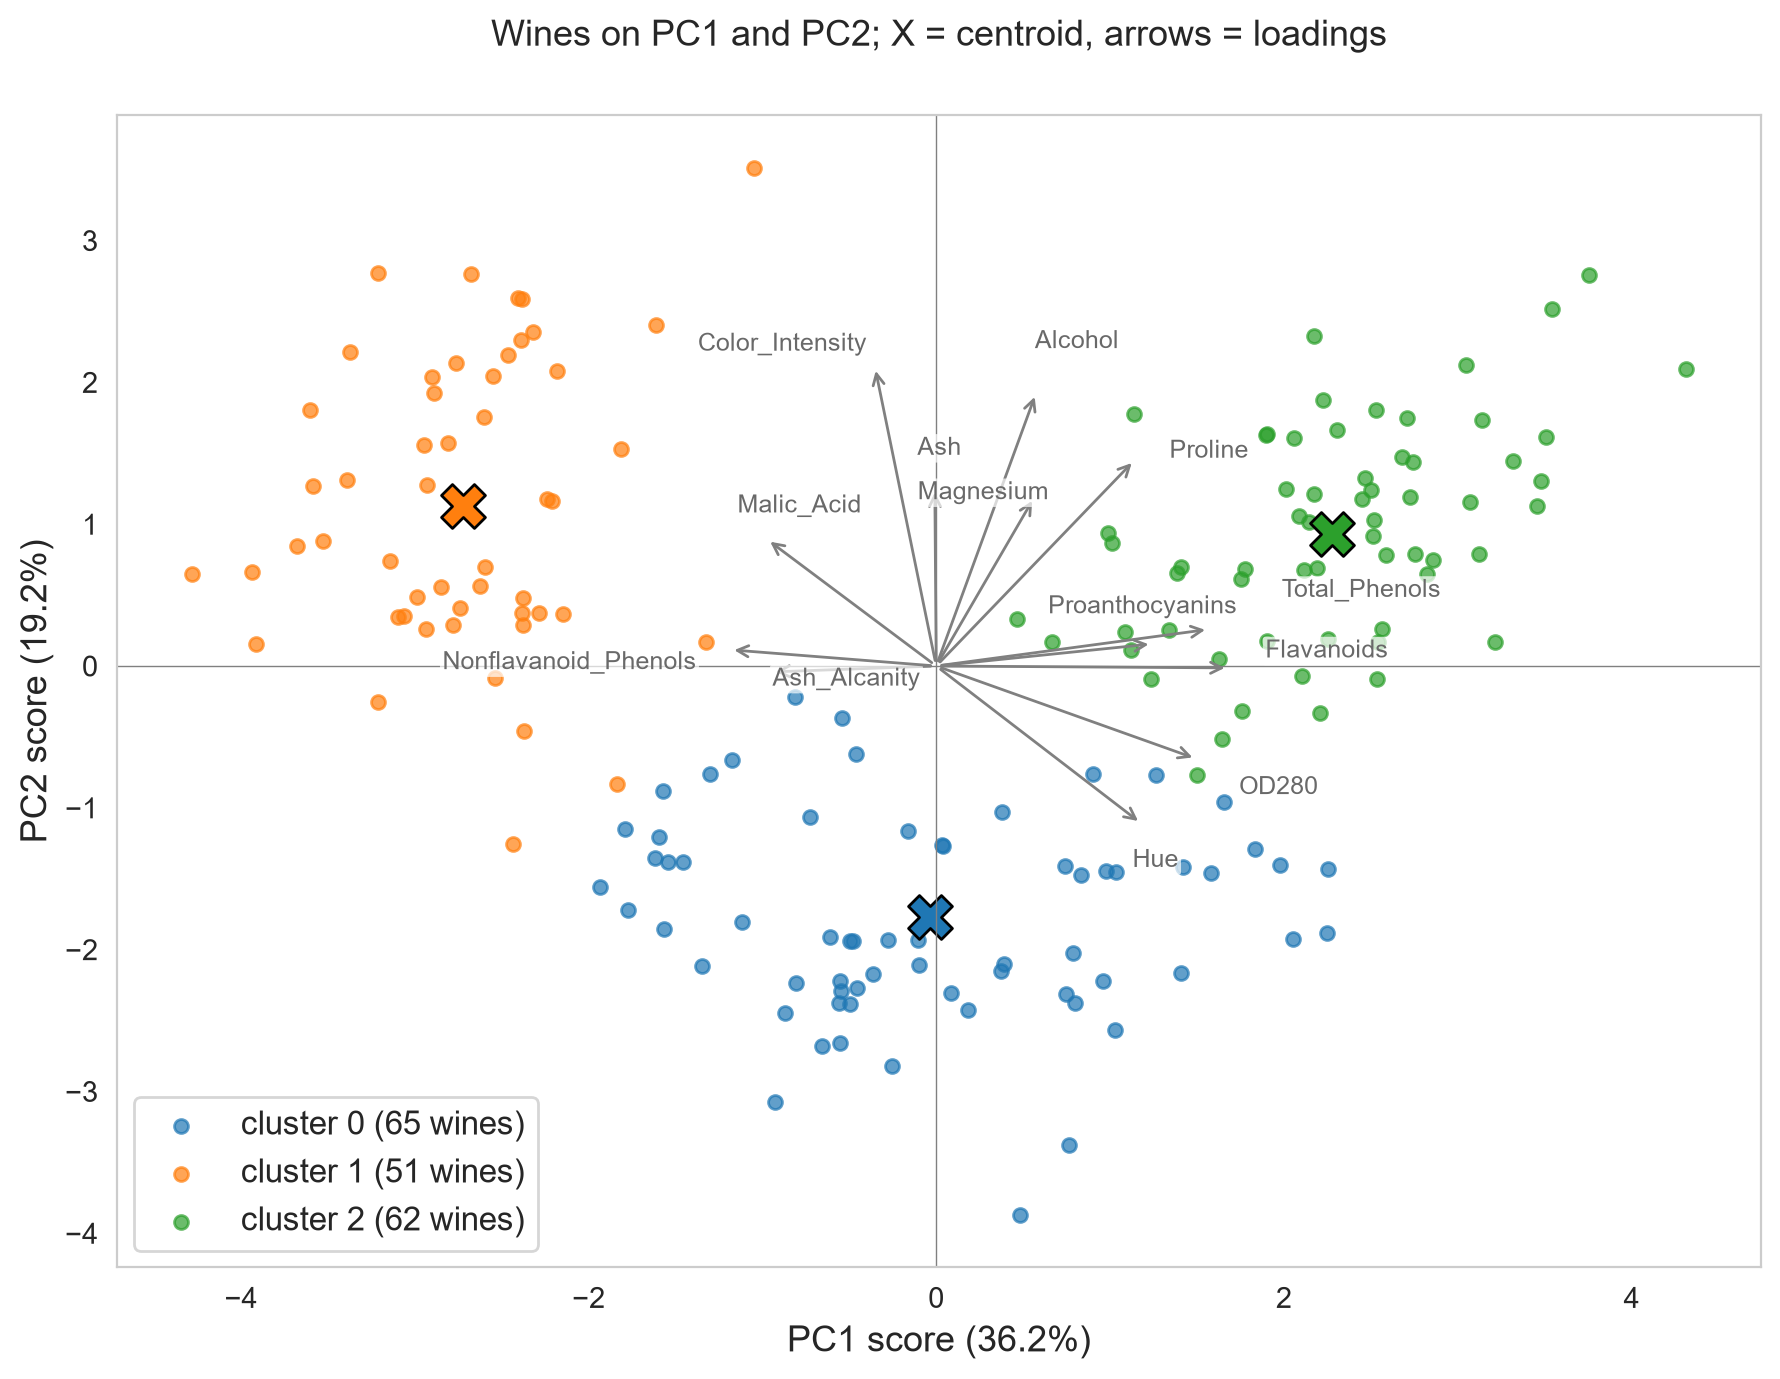

In [29]:
from sklearn.metrics import adjusted_rand_score
from adjustText import adjust_text

all_features = fit_kmeans(Z, K_WINE).labels_
print(f'Agreement with K-means on all 13 standardised features, adjusted Rand index (1 = identical): {adjusted_rand_score(all_features, clusters):.3f}')

fig, ax = plt.subplots(figsize=(9, 7))
for c in range(K_WINE):
    pick = clusters == c
    ax.scatter(scores[pick, 0], scores[pick, 1], s=25, alpha=0.7, color=COLOURS[c], label=f'cluster {c} ({pick.sum()} wines)')
    ax.scatter(*km_wine.cluster_centers_[c, :2], marker='X', s=250, color=COLOURS[c], edgecolor='black')
scale = 4
names = []
for feature, (lx, ly) in zip(wine.columns, pca.components_[:2].T):
    ax.annotate('', xy=(lx * scale, ly * scale), xytext=(0, 0), arrowprops=dict(arrowstyle='->', color='grey'))
    names.append(ax.text(lx * scale * 1.12, ly * scale * 1.12, feature, fontsize=9, color='dimgrey', ha='center', va='center',
                         bbox=dict(boxstyle='round,pad=0.1', facecolor='white', edgecolor='none', alpha=0.7)))
adjust_text(names, ax=ax)   # keeps the feature names from overlapping
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set(xlabel=f'PC1 score ({pca.explained_variance_ratio_[0]:.1%})', ylabel=f'PC2 score ({pca.explained_variance_ratio_[1]:.1%})',
       title='Wines on PC1 and PC2; X = centroid, arrows = loadings')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show();

**Reading the map.**
- **Cluster 1** (centroid at PC1 = −2.72, PC2 = 1.13) lies toward the `Color_Intensity` and `Malic_Acid` arrows and opposite the phenolic arrows (`Flavanoids`, `Total_Phenols`, `OD280`).
- **Cluster 2** (2.28, 0.93) lies toward the phenolic arrows, `Proline` and `Alcohol`.
- **Cluster 0** (−0.04, −1.77) lies in the negative PC2 direction, away from `Alcohol` and `Color_Intensity`.
- **Overlap**: clusters 0 and 2 meet around PC1 = 1 to 2, and a few wines of cluster 1 sit among cluster 0 near PC2 = −1, consistent with the moderate silhouette; the three groups are still clearly separated overall.

**Insights**
- **Three chemically distinct types of wine**: PC1 (phenolic content) separates clusters 1 and 2, and PC2 (alcohol and colour) sets cluster 0 apart; the clusters overlap on PC3 to PC5, so the grouping lives in PC1 and PC2.
- **Reduction cost nothing here**: K-means on the 5 PC scores gives the same clusters as on all 13 standardised features (adjusted Rand index 1.000), with 5 columns instead of 13.
- **Limit**: the sheet has no wine labels and the silhouette is moderate (0.369), so the groups are distinct in chemistry, not a confirmed grape variety.